# IndoBERT Clickbait Detection - Complete Pipeline

This notebook runs the complete training and evaluation pipeline for IndoBERT-based clickbait detection with robustness evaluation.

**Requirements:**
- GPU Runtime (T4 for testing, A100 for full training)
- 5 CSV files with columns: `id`, `source`, `date`, `title`, `Label`, `url`
  (one file per domain: technology.csv, politic.csv, health.csv, sport.csv, education.csv)
- ~(TBA) hours for complete execution

❗❗**BOLD -> changed**

---
**model: base**

**BertTokenizer**

DROPOUT_RATE: float = 0.1

# Hyperparameters
LEARNING_RATE: float = 2e-5

BATCH_SIZE: int = 32

NUM_EPOCHS: int = 4

WEIGHT_DECAY: float = 0.01

WARMUP_RATIO: float = 0.1

# Optimizer
OPTIMIZER: str = "AdamW"

EPSILON: float = 1e-8

MAX_GRAD_NORM: float = 1.0

# Early stopping
EARLY_STOPPING_PATIENCE: int = 2

EARLY_STOPPING_METRIC: str = "f1"

# Learning rate scheduler
SCHEDULER_TYPE: str = "linear"

In [3]:
# import zipfile

# with zipfile.ZipFile("ths_test.zip", "r") as zip_ref:
#     zip_ref.extractall("/content")

In [1]:
import os

os.environ["HF_HUB_DISABLE_XET"] = "1"

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# %cd /content
# !rm -rf domain-shift-trustworthy-ai

%cd /content/drive/MyDrive/
!rm -rf run_thesis

%cd /content
!rm -rf checkpoints_staging

%cd domain-shift-trustworthy-ai

/content/drive/MyDrive
/content
[Errno 2] No such file or directory: 'domain-shift-trustworthy-ai'
/content


## 1. Environment Setup

In [4]:
# Check GPU availability
!nvidia-smi

Fri Sep 18 16:23:42 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Clone repository or upload code files
# Option 1: Clone from GitHub
!git clone https://github.com/gredss/domain-shift-trustworthy-ai.git
%cd domain-shift-trustworthy-ai

# # Option 2: Upload files manually
# from google.colab import files
# import os

# print("Upload all Python files (.py) from your project")
# uploaded = files.upload()

# # List uploaded files
# !ls -lh *.py

Cloning into 'domain-shift-trustworthy-ai'...
remote: Enumerating objects: 559, done.
remote: Counting objects: 100% (214/214), done.
remote: Compressing objects: 100% (181/181), done.
remote: Total 559 (delta 128), reused 63 (delta 33), pack-reused 345 (from 1)
Receiving objects: 100% (559/559), 6.87 MiB | 13.78 MiB/s, done.
Resolving deltas: 100% (320/320), done.
/content/domain-shift-trustworthy-ai


In [5]:
path = "/content/domain-shift-trustworthy-ai/src/evaluation_engine.py"
with open(path, "r", encoding="utf-8") as f:
    content = f.read()
# Convert every tab character to 4 spaces
content = content.expandtabs(4)
with open(path, "w", encoding="utf-8") as f:
    f.write(content)
print("Converted all tabs to 4 spaces.")
#CHECK ========================================================
!python -m py_compile /content/domain-shift-trustworthy-ai/src/evaluation_engine.py

##############################
path = "/content/domain-shift-trustworthy-ai/src/evaluate_pipeline.py"
with open(path, "r", encoding="utf-8") as f:
    content = f.read()
# Convert every tab character to 4 spaces
content = content.expandtabs(4)
with open(path, "w", encoding="utf-8") as f:
    f.write(content)
print("Converted all tabs to 4 spaces.")
#CHECK ========================================================
!python -m py_compile /content/domain-shift-trustworthy-ai/src/evaluate_pipeline.py

###############
path = "/content/domain-shift-trustworthy-ai/src/perturbation_engine.py"
with open(path, "r", encoding="utf-8") as f:
    content = f.read()
# Convert every tab character to 4 spaces
content = content.expandtabs(4)
with open(path, "w", encoding="utf-8") as f:
    f.write(content)
print("Converted all tabs to 4 spaces.")
#CHECK ========================================================
!python -m py_compile /content/domain-shift-trustworthy-ai/src/perturbation_engine.py

Converted all tabs to 4 spaces.
Converted all tabs to 4 spaces.
Converted all tabs to 4 spaces.


In [6]:
# Install dependencies
!pip install -q torch transformers pandas numpy scikit-learn scipy streamlit plotly tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 84.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 110.4 MB/s eta 0:00:00


## 2. Data Preparation

In [7]:
# Create necessary directories
!mkdir -p dataset
!mkdir -p /content/drive/MyDrive/thesis/checkpoints
!mkdir -p /content/drive/MyDrive/thesis/results
!mkdir -p /content/drive/MyDrive/thesis/outputs

In [8]:
from pathlib import Path

DATA_DIR = Path("/content/domain-shift-trustworthy-ai/dataset/data")

# Verify the files exist
csv_files = list(DATA_DIR.glob("*.csv"))
print(csv_files)

[PosixPath('/content/domain-shift-trustworthy-ai/dataset/data/education.csv'), PosixPath('/content/domain-shift-trustworthy-ai/dataset/data/health.csv'), PosixPath('/content/domain-shift-trustworthy-ai/dataset/data/politic.csv'), PosixPath('/content/domain-shift-trustworthy-ai/dataset/data/sport.csv'), PosixPath('/content/domain-shift-trustworthy-ai/dataset/data/technology.csv')]


In [9]:
# ── DATA SANITY CHECK: per-domain CSV row counts and label balance ──────────
# Reads the raw CSV files only. No data is modified here.
import pandas as pd
import glob
import os

csv_files = sorted(
    glob.glob('/content/domain-shift-trustworthy-ai/dataset/data/*.csv')
)
print(f"Found {len(csv_files)} CSV files\n")

# Build one summary row per file so we can print a clean aligned table.
summary_rows = []
for csv_file in csv_files:
    df = pd.read_csv(csv_file)
    label_counts = df['Label'].value_counts().to_dict()
    n_non = int(label_counts.get(0, 0))   # 0 = non-clickbait
    n_click = int(label_counts.get(1, 0))  # 1 = clickbait
    total = len(df)
    summary_rows.append({
        "file": os.path.basename(csv_file),
        "rows": total,
        "non_clickbait": n_non,
        "clickbait": n_click,
        "clickbait_ratio": (n_click / total) if total else 0.0,
    })

# Print an aligned table.
print(f"{'File':<20}{'Rows':>7}{'Non-CB':>9}{'CB':>7}{'CB ratio':>10}")
print("-" * 53)
for r in summary_rows:
    print(
        f"{r['file']:<20}"
        f"{r['rows']:>7}"
        f"{r['non_clickbait']:>9}"
        f"{r['clickbait']:>7}"
        f"{r['clickbait_ratio']:>10.3f}"
    )

# Totals row.
total_rows = sum(r['rows'] for r in summary_rows)
total_non = sum(r['non_clickbait'] for r in summary_rows)
total_click = sum(r['clickbait'] for r in summary_rows)
print("-" * 53)
print(
    f"{'TOTAL':<20}"
    f"{total_rows:>7}"
    f"{total_non:>9}"
    f"{total_click:>7}"
    f"{(total_click / total_rows if total_rows else 0):>10.3f}"
)


Found 5 CSV files

File                   Rows   Non-CB     CB  CB ratio
-----------------------------------------------------
education.csv          1000      650    350     0.350
health.csv             1000      624    376     0.376
politic.csv            1000      813    187     0.187
sport.csv              1000      763    237     0.237
technology.csv         1000      772    228     0.228
-----------------------------------------------------
TOTAL                  5000     3622   1378     0.276


In [ ]:
# # Quick data verification from the existing dataset/data folder CSV files
# import pandas as pd
# import glob

# csv_files = glob.glob('dataset/data/*.csv')
# print(f"Found {len(csv_files)} CSV files\n")

# for csv_file in csv_files:
#     df = pd.read_csv(csv_file, sep=';')
#     print(f"{csv_file}:")
#     print(f"  Rows: {len(df)}")
#     print(f"  Columns: {list(df.columns)}")
#     print(f"  Label distribution: {df['Label'].value_counts().to_dict()}")
#     print()

## 3. Model Training

Train IndoBERT models. Start with base model for testing, then scale to all models.

In [12]:
# %cd domain-shift-trustworthy-ai

# Train base model (recommended for initial testing)
# Trains one specialist model per domain (5 specialists x 1 variant = 5 models)
!python src/train_pipeline.py \
    --model base \
    --dataset-dir dataset/data \
    --checkpoint-dir /content/drive/MyDrive/thesis/checkpoints \
    --output-dir /content/drive/MyDrive/thesis/outputs \
    --device cuda \
    --seed 42 \
    --debug #\
    #--grid-search

# !python src/train_pipeline.py \
#     --model base \
#     --dataset-dir /content/domain-shift-trustworthy-ai/dataset/data \
#     --checkpoint-dir "/content/drive/MyDrive/BINUS/Prethesis and Thesis/experiment/checkpoints" \
#     --output-dir "/content/drive/MyDrive/BINUS/Prethesis and Thesis/experiment/output" \
#     --device cuda \
#     --seed 42 \
#     --debug

2026-09-18 16:26:29,431 - INFO - [debug_logger] Debug output ENABLED for this run
2026-09-18 16:26:29,567 - INFO - Training Pipeline initialized
2026-09-18 16:26:29,567 - INFO - Dataset: dataset/data, Output: /content/drive/MyDrive/thesis/outputs, Checkpoints: /content/drive/MyDrive/thesis/checkpoints
2026-09-18 16:26:29,567 - INFO - Device: cuda, Random seed: 42
2026-09-18 16:26:29,567 - INFO - 
Starting SPECIALIST Training Pipeline
2026-09-18 16:26:29,567 - INFO - 
[STEP 1] Loading and Preparing Data
2026-09-18 16:26:29,567 - INFO - DataManager initialized with seed=42, max_length=128
2026-09-18 16:26:29,567 - INFO - Loading 5 CSV files

[DataManager] ──── Data quality check  →  Technology ───────────────────────────
    null_titles: 0
    short_titles: 0
    long_titles: 0
    duplicate_titles: 0
2026-09-18 16:26:29,579 - INFO - Loaded 1000 samples from technology.csv (domain: Technology)

[DataManager] ──── CSV loaded  →  domain=Technology ────────────────────────────
    file     

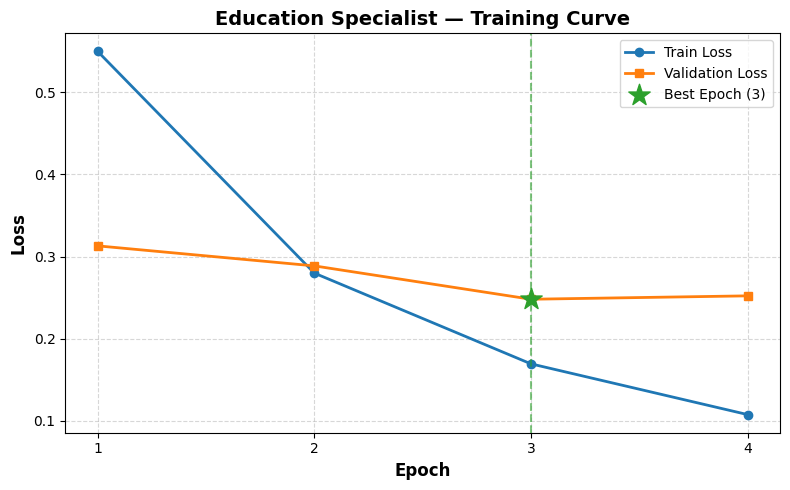

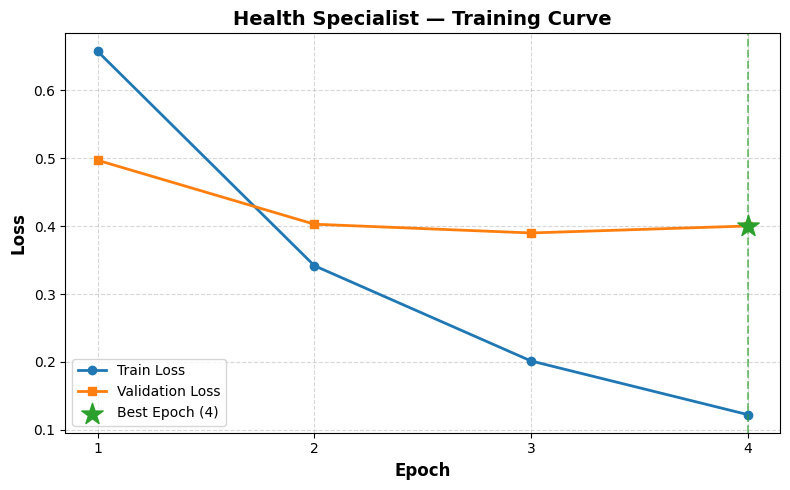

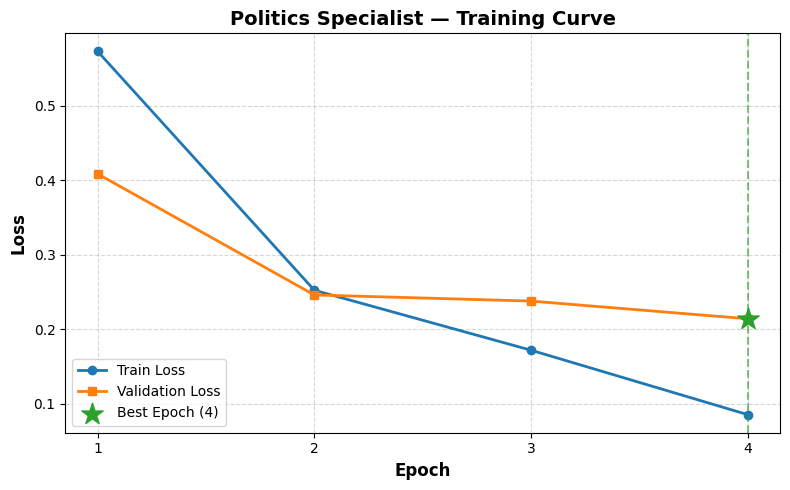

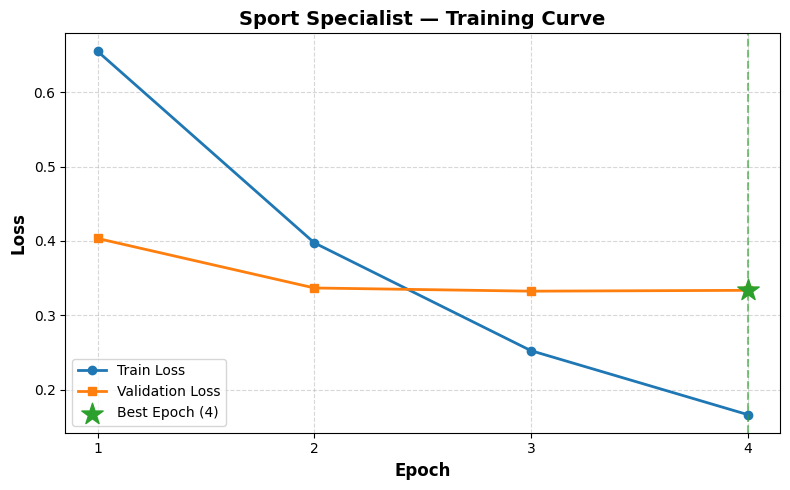

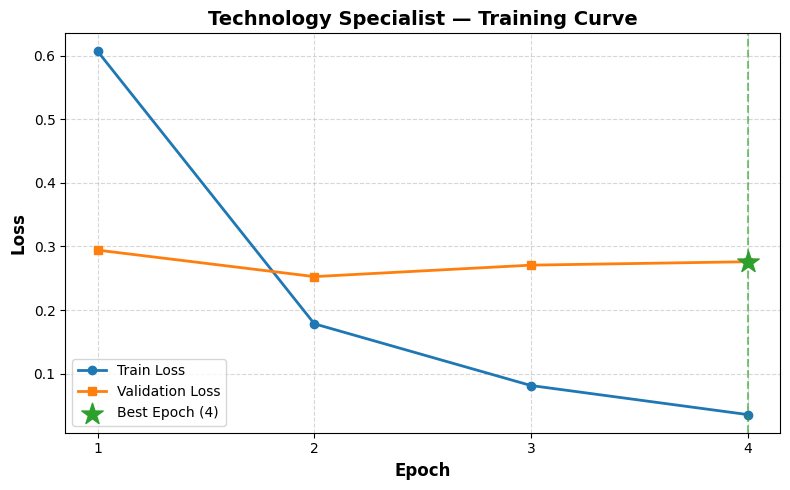

In [13]:
# ── TRAINING CURVES: train vs. validation loss per domain specialist ────────
# Reads the saved training_history.json files only. Training itself is done in
# the pipeline cell above; nothing here changes the model or its training.
import json
import os
import matplotlib.pyplot as plt

CKPT_ROOT = "/content/drive/MyDrive/thesis/checkpoints/base"
DOMAINS = ["Education", "Health", "Politics", "Sport", "Technology"]

for domain in DOMAINS:
    history_path = os.path.join(CKPT_ROOT, domain, "training_history.json")
    with open(history_path, "r") as f:
        history = json.load(f)

    epochs = history["epochs"]
    train_loss = history["train_loss"]
    val_loss = history["val_loss"]
    val_macro_f1 = history["val_macro_f1"]

    # Best epoch = the one with the highest validation Macro-F1.
    best_idx = val_macro_f1.index(max(val_macro_f1))
    best_epoch = epochs[best_idx]
    best_val_loss = val_loss[best_idx]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(epochs, train_loss, marker="o", linewidth=2,
            color="tab:blue", label="Train Loss")
    ax.plot(epochs, val_loss, marker="s", linewidth=2,
            color="tab:orange", label="Validation Loss")

    # Mark the best epoch clearly.
    ax.scatter([best_epoch], [best_val_loss], marker="*", s=260,
               color="tab:green", zorder=5,
               label=f"Best Epoch ({best_epoch})")
    ax.axvline(best_epoch, linestyle="--", linewidth=1.5,
               color="tab:green", alpha=0.6)

    ax.set_title(f"{domain} Specialist — Training Curve",
                 fontsize=14, fontweight="bold")
    ax.set_xlabel("Epoch", fontsize=12, fontweight="bold")
    ax.set_ylabel("Loss", fontsize=12, fontweight="bold")
    ax.set_xticks(epochs)
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(frameon=True)
    fig.tight_layout()
    plt.show()
    plt.close(fig)


In [14]:
# ── CHECKPOINT SANITY CHECK: does each domain specialist exist? ─────────────
import os

CKPT_ROOT = "/content/drive/MyDrive/thesis/checkpoints/base"
DOMAINS = ["Education", "Health", "Politics", "Sport", "Technology"]

print(f"{'Domain':<14}{'Checkpoint found':>18}")
print("-" * 32)
all_present = True
for domain in DOMAINS:
    ckpt = os.path.join(CKPT_ROOT, domain, "best_model.pt")
    present = os.path.exists(ckpt)
    all_present = all_present and present
    status = "yes" if present else "MISSING"
    print(f"{domain:<14}{status:>18}")
print("-" * 32)
print("All specialists present." if all_present
      else "WARNING: at least one specialist checkpoint is missing.")


Domain          Checkpoint found
--------------------------------
Education                    yes
Health                       yes
Politics                     yes
Sport                        yes
Technology                   yes
--------------------------------
All specialists present.


In [ ]:
# Train all models (base, large, lite) - Use A100 GPU for this
# Uncomment to run:
# !python src/train_pipeline.py \
#     --model all \
#     --dataset-dir dataset \
#     --checkpoint-dir /content/drive/MyDrive/thesis/checkpoints \
#     --output-dir /content/drive/MyDrive/thesis/output \
#     --device cuda \
#     --seed 42

In [ ]:
# Optional: Train with hyperparameter grid search
# !python src/train_pipeline.py \
#     --model base \
#     --dataset-dir dataset \
#     --checkpoint-dir /content/drive/MyDrive/thesis/checkpoints \
#     --output-dir /content/drive/MyDrive/thesis/output \
#     --device cuda \
#     --grid-search \
#     --seed 42

## 4. Model Evaluation

Run comprehensive evaluation including in-domain, cross-domain, and perturbation testing.

In [15]:
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 7.4 MB/s eta 0:00:00


**USE HIGHEST CONTEXTUAL SIMILARITY**

```
best = max(
          candidates,
          key=lambda x: x["similarity"],
      )
```



In [16]:
# Evaluate base model with full perturbation testing
# --train-output-dir must match --output-dir used in train_pipeline.py
# so evaluation reuses the exact same test splits the model never saw during training.
!python src/evaluate_pipeline.py \
    --model base \
    --checkpoint-dir /content/drive/MyDrive/thesis/checkpoints \
    --dataset-dir dataset/data \
    --output-dir /content/drive/MyDrive/thesis/results \
    --train-output-dir /content/drive/MyDrive/thesis/outputs/ \
    --device cuda \
    --seed 42 \
    --debug

Streaming output truncated to the last 5000 lines.

[ModelTrainer] ──── Predict ─────────────────────────────────────────────────────
    texts      : 150
    batch_size : 32

[ClickbaitDataset] ──── Dataset created  (predict) ──────────────────────────────────
    total     : 150
    clickbait : 0  (0.0%)
    non-cb    : 150  (100.0%)

[Tokenizer] ──── Sample encodings  (max_length=128) ──────────────────────────
  sample [0]  label=non-clickbait
    original   : Rekap Hasil Singapore Open 2026, Fajar/Fikri Wakil Indonesia di Final
    input_ids  : [2, 1373, 36, 562, 10500, 7426, 23917, 30385, 30468, 12009] … (total=128, real=17)
    attn_mask  : [1, 1, 1, 1, 1, 1, 1, 1, 1, 1] … (n_pad=111)
    decoded    : [CLS] rekap hasil singapore open 2026, fajar / fikri wakil indonesia di final [SEP]
  sample [1]  label=non-clickbait
    original   : Klasemen Grup B Piala AFF U19 2026, Thailand dan Malaysia Incar Puncak
    input_ids  : [2, 10502, 4343, 13, 4353, 11007, 489, 1797, 23917, 30385] 

In [52]:
import os
import pandas as pd


# ============================================================
# CONFIG
# ============================================================

BASE_DIR = "/content/drive/MyDrive/thesis/results/base"

DOMAINS = [
    "education",
    "health",
    "politics",
    "sport",
    "technology"
]

LEVELS = ["low", "medium", "high"]

# Added technique folder as seen in directory tree
TECHNIQUE = "semantic"


# ============================================================
# LOAD DATA (FIXED)
# ============================================================

def load_domain_data(domain):
    # Updated path to include the 'semantic' subfolder
    domain_dir = os.path.join(BASE_DIR, domain, TECHNIQUE)
    dfs = {}

    for level in LEVELS:
        path = os.path.join(domain_dir, f"{level}.csv")

        if not os.path.exists(path):
            raise FileNotFoundError(f"Missing file: {path}")

        df = pd.read_csv(path)

        if "id" in df.columns:
            df = df.set_index("id")

        dfs[level] = df

    return dfs


# ============================================================
# CLASSIFY TEXT PATTERN
# ============================================================

def classify_perturbation(low_row, medium_row, high_row):

    low_success = bool(low_row["perturbation_in_range"])
    medium_success = bool(medium_row["perturbation_in_range"])
    high_success = bool(high_row["perturbation_in_range"])

    # Any failed level is handled separately.
    if not (low_success and medium_success and high_success):
        return None

    low = str(low_row["perturbed_text"])
    medium = str(medium_row["perturbed_text"])
    high = str(high_row["perturbed_text"])

    low_eq_medium = low == medium
    low_eq_high = low == high
    medium_eq_high = medium == high

    if low_eq_medium and medium_eq_high:
        return "Low = Medium = High"

    if medium_eq_high and not low_eq_medium:
        return "Medium = High != Low"

    if low_eq_medium and not low_eq_high:
        return "Low = Medium != High"

    if low_eq_high and not low_eq_medium:
        return "Low = High != Medium"

    return "Low != Medium != High"


# ============================================================
# ANALYZE ONE DOMAIN
# ============================================================

def analyze_domain(domain):

    dfs = load_domain_data(domain)

    low_df = dfs["low"]
    medium_df = dfs["medium"]
    high_df = dfs["high"]

    common_ids = (
        low_df.index
        .intersection(medium_df.index)
        .intersection(high_df.index)
    )

    if len(common_ids) == 0:
        raise ValueError(
            f"No common samples found for domain: {domain}"
        )

    results = []

    for sample_id in common_ids:

        low_row = low_df.loc[sample_id]
        medium_row = medium_df.loc[sample_id]
        high_row = high_df.loc[sample_id]

        low_success = bool(
            low_row["perturbation_in_range"]
        )

        medium_success = bool(
            medium_row["perturbation_in_range"]
        )

        high_success = bool(
            high_row["perturbation_in_range"]
        )

        pattern = classify_perturbation(
            low_row,
            medium_row,
            high_row
        )

        results.append({
            "id": sample_id,
            "low_success": low_success,
            "medium_success": medium_success,
            "high_success": high_success,
            "pattern": pattern
        })

    return pd.DataFrame(results)


# ============================================================
# RUN ALL DOMAINS
# ============================================================

all_details = {}
all_summaries = []


for domain in DOMAINS:

    detail_df = analyze_domain(domain)

    all_details[domain] = detail_df

    all_summaries.append({
        "domain": domain,
        "total_samples": len(detail_df),

        "low_success": int(
            detail_df["low_success"].sum()
        ),

        "low_failed": int(
            (~detail_df["low_success"]).sum()
        ),

        "medium_success": int(
            detail_df["medium_success"].sum()
        ),

        "medium_failed": int(
            (~detail_df["medium_success"]).sum()
        ),

        "high_success": int(
            detail_df["high_success"].sum()
        ),

        "high_failed": int(
            (~detail_df["high_success"]).sum()
        )
    })


# ============================================================
# FINAL SUMMARY
# ============================================================

summary_df = pd.DataFrame(all_summaries)


# ============================================================
# PRINT: SUCCESS / FAILED PER LEVEL
# ============================================================

print("=" * 80)
print("PERTURBATION SUCCESS / FAILURE BY LEVEL")
print("=" * 80)


for level in LEVELS:

    print("\n" + "-" * 80)
    print(f"{level.upper()} LEVEL")
    print("-" * 80)

    success_col = f"{level}_success"
    failed_col = f"{level}_failed"

    print(
        f"{'Domain':<15}"
        f"{'Success':>12}"
        f"{'Failed':>12}"
        f"{'Total':>12}"
    )

    print("-" * 51)

    for _, row in summary_df.iterrows():

        print(
            f"{row['domain'].upper():<15}"
            f"{row[success_col]:>12}"
            f"{row[failed_col]:>12}"
            f"{row['total_samples']:>12}"
        )

    print("-" * 51)

    print(
        f"{'TOTAL':<15}"
        f"{summary_df[success_col].sum():>12}"
        f"{summary_df[failed_col].sum():>12}"
        f"{summary_df['total_samples'].sum():>12}"
    )


# ============================================================
# SUCCESSFUL TEXT PATTERNS PER DOMAIN
# ============================================================

# ============================================================
# SUCCESSFUL / FAILED PERTURBATION PATTERNS PER DOMAIN
# ============================================================

print("\n\n")
print("=" * 80)
print("PERTURBATION PATTERNS BY DOMAIN")
print("=" * 80)

for domain, detail_df in all_details.items():

    counts = detail_df["pattern"].value_counts()

    # Failed = at least one perturbation level failed
    failed_count = (
        (~detail_df["low_success"])
        | (~detail_df["medium_success"])
        | (~detail_df["high_success"])
    ).sum()

    print("\n" + "-" * 80)
    print(f"DOMAIN: {domain.upper()}")
    print("-" * 80)

    print(
        f"Failed:                     "
        f"{failed_count}"
    )

    print(
        f"Low = Medium = High:       "
        f"{counts.get('Low = Medium = High', 0)}"
    )

    print(
        f"Medium = High != Low:      "
        f"{counts.get('Medium = High != Low', 0)}"
    )

    print(
        f"Low = Medium != High:      "
        f"{counts.get('Low = Medium != High', 0)}"
    )

    print(
        f"Low = High != Medium:      "
        f"{counts.get('Low = High != Medium', 0)}"
    )

    print(
        f"Low != Medium != High:     "
        f"{counts.get('Low != Medium != High', 0)}"
    )


# ============================================================
# FINAL TABLE
# ============================================================

print("\n\n")
print("=" * 80)
print("FINAL SUMMARY TABLE")
print("=" * 80)

print(
    summary_df.to_string(index=False)
)



PERTURBATION SUCCESS / FAILURE BY LEVEL

--------------------------------------------------------------------------------
LOW LEVEL
--------------------------------------------------------------------------------
Domain              Success      Failed       Total
---------------------------------------------------
EDUCATION               142           8         150
HEALTH                  144           6         150
POLITICS                142           8         150
SPORT                   132          18         150
TECHNOLOGY              130          20         150
---------------------------------------------------
TOTAL                   690          60         750

--------------------------------------------------------------------------------
MEDIUM LEVEL
--------------------------------------------------------------------------------
Domain              Success      Failed       Total
---------------------------------------------------
EDUCATION               142           8

In [21]:
# ── QUICK PEEK: one perturbed result per mechanism, to confirm the nested JSON
# Structure: results["perturbation"][domain]["clean" | "semantic" | "typo"][level]
import json

PERTURB_TYPES = ["semantic", "typo"]
PERTURB_LEVELS = ["low", "medium", "high"]

path = "/content/drive/MyDrive/thesis/results/base/complete_evaluation.json"
with open(path, "r", encoding="utf-8") as f:
    results = json.load(f)

# Show the first domain, first level of each mechanism as a structure check.
first_domain = next(iter(results["perturbation"]))
domain_block = results["perturbation"][first_domain]
print("DOMAIN:", first_domain)
print("Top-level keys:", list(domain_block.keys()))  # expect: clean, semantic, typo

for ptype in PERTURB_TYPES:
    level = PERTURB_LEVELS[0]
    result = domain_block[ptype][level]
    print(f"\n--- {ptype.upper()} / {level.upper()} ---")
    print("Macro-F1:", result["metrics"]["macro_f1"])
    print("Similarity:",
          result["perturbation_statistics"]["semantic_similarity"])
    print("Flip:", result.get("prediction_flip", {}).get("flip_rate_pct"))


DOMAIN: Education
Top-level keys: ['clean', 'semantic', 'typo']

--- SEMANTIC / LOW ---
Macro-F1: 0.8775157308228061
Similarity: {'count': 144, 'mean': 0.8469828193386396, 'median': 0.8391922414302826, 'std': 0.03380410830589448, 'min': 0.8001872301101685, 'max': 0.9492011070251465}
Flip: 2.666666666666667

--- TYPO / LOW ---
Macro-F1: 0.7814473045167557
Similarity: {'count': 0, 'mean': None, 'median': None, 'std': None, 'min': None, 'max': None}
Flip: 14.666666666666666


In [22]:
import os

# ============================================================
# CONFIG
# ============================================================

PROJECT_ROOT = "/content/drive/MyDrive/thesis"
MODEL = "base"

# Core directories
RESULTS_ROOT = os.path.join(PROJECT_ROOT, "results")
OUTPUTS_ROOT = os.path.join(PROJECT_ROOT, "outputs")

# Model-specific directories
RESULTS_DIR = os.path.join(RESULTS_ROOT, MODEL)
OUTPUT_DIR = os.path.join(OUTPUTS_ROOT, MODEL, "evaluation_results")

# Files
COMPLETE_EVALUATION_JSON = os.path.join(
    RESULTS_DIR,
    "complete_evaluation.json"
)

CROSS_DOMAIN_PERTURBATION_JSON = os.path.join(
    RESULTS_DIR,
    "cross_domain_perturbation_results.json"
)

EVALUATION_SUMMARY_JSON = os.path.join(
    RESULTS_ROOT,
    "evaluation_summary.json"
)

TRAINING_SUMMARY_JSON = os.path.join(
    OUTPUTS_ROOT,
    "training_summary.json"
)

# Data splits
SPLITS_DIR = os.path.join(
    OUTPUTS_ROOT,
    "data_splits"
)

# Domains / perturbation
DOMAINS = [
    "Education",
    "Health",
    "Politics",
    "Sport",
    "Technology"
]

PERTURB_LEVELS = [
    "clean",
    "low",
    "medium",
    "high"
]

# Metrics
METRICS_TO_PLOT = {
    "macro_f1": "Macro-F1",
    "f1_0": "F1₀ (Non-Clickbait)",
    "f1_1": "F1₁ (Clickbait)"
}

**testing prediction flip**

PREDICTION FLIP ANALYSIS  (per domain / mechanism / level)
    domain     type  level  flip_rate_pct  flip_0_to_1_count  flip_1_to_0_count  correct_to_incorrect  incorrect_to_correct
 Education semantic    low       2.666667                  2                  2                     0                     4
 Education semantic medium       4.666667                  2                  5                     3                     4
 Education semantic   high       3.333333                  2                  3                     1                     4
 Education     typo    low      14.666667                  0                 22                    14                     8
 Education     typo medium      26.666667                  1                 39                    26                    14
 Education     typo   high      29.333333                  0                 44                    32                    12
    Health semantic    low       2.000000                  1             

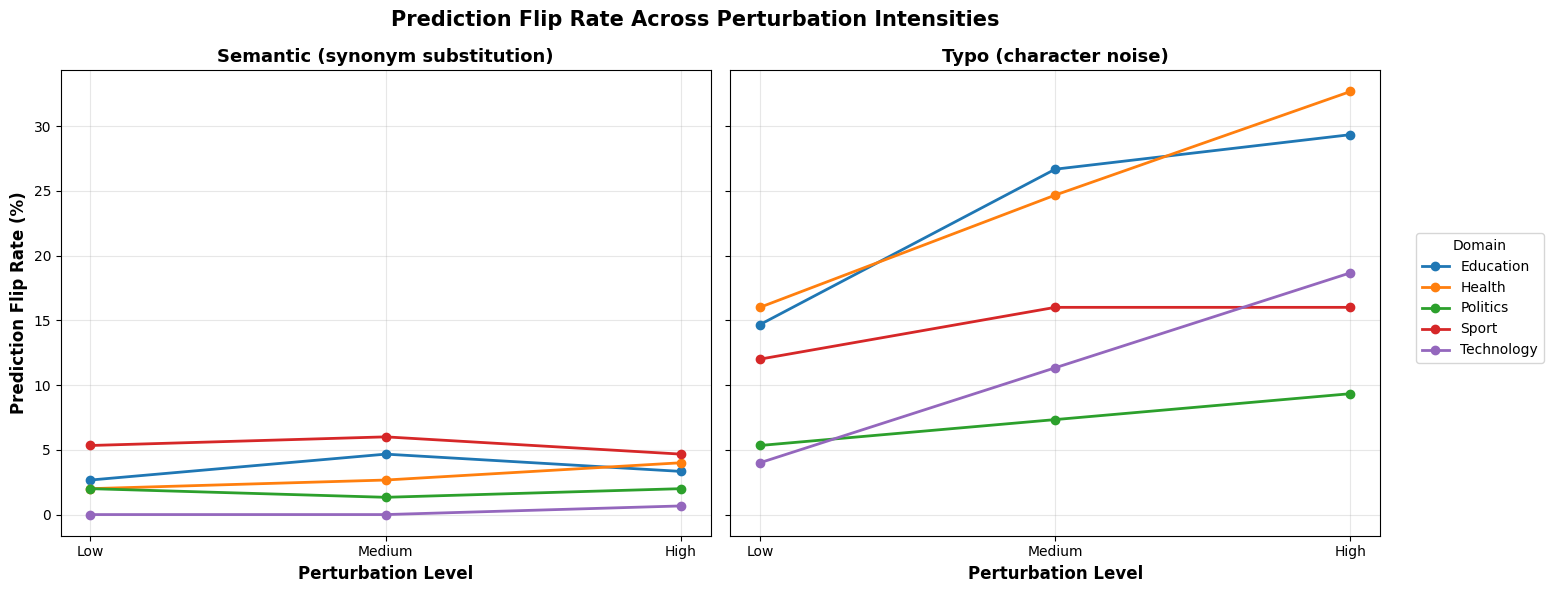

In [23]:
# ── PREDICTION FLIP ANALYSIS ────────────────────────────────────────────────
# How often does a perturbation flip the predicted label? We compute this per
# domain, per mechanism (semantic/typo), per level, from the nested results.
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

with open(COMPLETE_EVALUATION_JSON, "r", encoding="utf-8") as f:
    results = json.load(f)

PERTURB_TYPES = ["semantic", "typo"]
PERTURB_LEVELS = ["low", "medium", "high"]
PERTURB_TYPE_LABELS = {
    "semantic": "Semantic (synonym substitution)",
    "typo": "Typo (character noise)",
}

# ---- Flatten the nested flip data into one tidy DataFrame ---------------
rows = []
for domain, domain_block in results["perturbation"].items():
    for ptype in PERTURB_TYPES:
        for level in PERTURB_LEVELS:
            level_block = domain_block.get(ptype, {}).get(level)
            if level_block is None:
                continue
            flip = level_block.get("prediction_flip", {})
            rows.append({
                "domain": domain,
                "type": ptype,
                "level": level,
                "flip_rate_pct": flip.get("flip_rate_pct", 0),
                "flip_0_to_1_count": flip.get("flip_0_to_1_count", 0),
                "flip_1_to_0_count": flip.get("flip_1_to_0_count", 0),
                "correct_to_incorrect":
                    flip.get("flips", {}).get("correct_to_incorrect", 0),
                "incorrect_to_correct":
                    flip.get("flips", {}).get("incorrect_to_correct", 0),
            })

df = pd.DataFrame(rows)

# ---- Print the full flip table -------------------------------------------
print("=" * 80)
print("PREDICTION FLIP ANALYSIS  (per domain / mechanism / level)")
print("=" * 80)
print(df.to_string(index=False))

# ---- Average flip rate by level, split by mechanism ----------------------
print("\n" + "=" * 80)
print("AVERAGE FLIP RATE (%) BY LEVEL AND MECHANISM")
print("=" * 80)
pivot_avg = (
    df.pivot_table(index="level", columns="type",
                   values="flip_rate_pct", aggfunc="mean")
      .reindex(index=PERTURB_LEVELS, columns=PERTURB_TYPES)
)
print(pivot_avg.round(2).to_string())

# ---- Chart: flip rate vs. intensity, two subplots (semantic | typo) ------
x_base = np.arange(len(PERTURB_LEVELS))
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
for ax, ptype in zip(axes, PERTURB_TYPES):
    sub = df[df["type"] == ptype]
    for domain in sub["domain"].unique():
        dom_rows = (
            sub[sub["domain"] == domain]
            .set_index("level")
            .reindex(PERTURB_LEVELS)
        )
        ax.plot(x_base, dom_rows["flip_rate_pct"].values,
                marker="o", linewidth=2, label=domain)
    ax.set_title(PERTURB_TYPE_LABELS[ptype], fontsize=13, fontweight="bold")
    ax.set_xlabel("Perturbation Level", fontsize=12, fontweight="bold")
    ax.set_xticks(x_base)
    ax.set_xticklabels([l.capitalize() for l in PERTURB_LEVELS])
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("Prediction Flip Rate (%)", fontsize=12, fontweight="bold")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Domain",
           bbox_to_anchor=(1.01, 0.5), loc="center left", frameon=True)
fig.suptitle("Prediction Flip Rate Across Perturbation Intensities",
             fontsize=15, fontweight="bold")
fig.tight_layout()
plt.show()
plt.close(fig)


In [24]:
# ── FLIP AMONG SUCCESSFUL PERTURBATIONS ONLY (per mechanism) ────────────────
# "Successful" = the perturbation actually changed the text within range.
PERTURB_TYPES = ["semantic", "typo"]
PERTURB_LEVELS = ["low", "medium", "high"]

for domain, domain_block in results["perturbation"].items():
    print("\n" + "=" * 80)
    print(domain.upper())
    print("=" * 80)
    for ptype in PERTURB_TYPES:
        print(f"\n  {ptype.upper()}")
        for level in PERTURB_LEVELS:
            level_block = domain_block.get(ptype, {}).get(level)
            if level_block is None:
                continue
            flip = level_block.get("prediction_flip", {})
            print(f"    {level.capitalize():<8} "
                  f"successful={flip.get('successful_perturbations')}  "
                  f"flips(successful-only)={flip.get('flip_count_successful_only')}  "
                  f"rate={flip.get('flip_rate_successful_only_pct')}%")



EDUCATION

  SEMANTIC
    Low      successful=142  flips(successful-only)=4  rate=2.8169014084507045%
    Medium   successful=142  flips(successful-only)=7  rate=4.929577464788732%
    High     successful=142  flips(successful-only)=5  rate=3.5211267605633805%

  TYPO
    Low      successful=150  flips(successful-only)=22  rate=14.666666666666666%
    Medium   successful=148  flips(successful-only)=38  rate=25.675675675675674%
    High     successful=28  flips(successful-only)=4  rate=14.285714285714285%

HEALTH

  SEMANTIC
    Low      successful=144  flips(successful-only)=3  rate=2.083333333333333%
    Medium   successful=145  flips(successful-only)=4  rate=2.7586206896551726%
    High     successful=145  flips(successful-only)=6  rate=4.137931034482759%

  TYPO
    Low      successful=150  flips(successful-only)=24  rate=16.0%
    Medium   successful=150  flips(successful-only)=37  rate=24.666666666666668%
    High     successful=41  flips(successful-only)=16  rate=39.024390243902

In [25]:
# Quick evaluation (skip perturbation testing for faster results)
# !python src/evaluate_pipeline.py \
#     --model base \
#     --checkpoint-dir /content/drive/MyDrive/thesis/checkpoints \
#     --dataset-dir dataset/data \
#     --output-dir /content/drive/MyDrive/thesis/results \
#     --train-output-dir /content/drive/MyDrive/thesis/output \
#     --device cuda \
#     --skip-perturbation \
#     --seed 42

In [26]:
# Evaluate all models (if you trained all)
# !python src/evaluate_pipeline.py \
#     --model all \
#     --checkpoint-dir /content/drive/MyDrive/thesis/checkpoints \
#     --dataset-dir dataset/data \
#     --output-dir /content/drive/MyDrive/thesis/results \
#     --train-output-dir /content/drive/MyDrive/thesis/output \
#     --device cuda \
#     --seed 42

## **Perturbation Check**

In [ ]:
# ── INPUT: clean test text  |  OUTPUT: perturbed text per level ──────────────
import sys
sys.path.insert(0, "/content/domain-shift-trustworthy-ai/src")

import pandas as pd
from perturbation_engine import PerturbationEngine

engine = PerturbationEngine(thesaurus_path="/content/dict.json",random_seed=42)

# Pick 3 samples from the Technology test split for a concrete demonstration
test_df = pd.read_csv(f"{SPLITS_DIR}/technology/test.csv")
samples = test_df.sample(n=3, random_state=0)["text"].tolist()

SEP = "═" * 80
for i, original in enumerate(samples):
    low    = engine.apply_perturbation(original, "low")
    medium = engine.apply_perturbation(original, "medium")
    high   = engine.apply_perturbation(original, "high")

    # Compute simple char-change ratio
    def change_ratio(a, b):
        return sum(x != y for x, y in zip(a, b)) / max(len(a), 1)

    print(f"\n{SEP}")
    print(f"Sample {i+1}")
    print(f"{SEP}")
    print(f"  ORIGINAL  : {original}")
    print(f"  LOW       : {low}")
    print(f"             char-change = {change_ratio(original, low):.1%}")
    print(f"  MEDIUM    : {medium}")
    print(f"             char-change = {change_ratio(original, medium):.1%}")
    print(f"  HIGH      : {high}")
    print(f"             char-change = {change_ratio(original, high):.1%}")
print(SEP)

**Perturbation Intensity Validation**

In [61]:
# ============================================================
# CONFIG
# ============================================================

BASE_DIR = "/content/drive/MyDrive/thesis/results/base"

DOMAINS = [
    "education",
    "health",
    "politics",
    "sport",
    "technology"
]

LEVELS = [
    "low",
    "medium",
    "high"
]

# 2. Added TECHNIQUE subfolder to match your file structure
TECHNIQUE = "semantic"


# ============================================================
# WORD-LEVEL CHANGE CALCULATION
# ============================================================

def calculate_word_changes(original, perturbed):
    """
    Calculate actual word changes using position-based comparison.

    Example:
        original  = "A B C D"
        perturbed = "A X C Y"

        changed words = 2
        ratio = 2 / 4 = 0.50
    """

    original_words = str(original).split()
    perturbed_words = str(perturbed).split()

    original_count = len(original_words)

    if original_count == 0:
        return {
            "actual_replacements": 0,
            "actual_ratio": 0.0
        }

    max_len = max(
        len(original_words),
        len(perturbed_words)
    )

    changed_words = sum(
        1
        for i in range(max_len)
        if (
            i >= len(original_words)
            or i >= len(perturbed_words)
            or original_words[i] != perturbed_words[i]
        )
    )

    ratio = changed_words / original_count

    return {
        "actual_replacements": changed_words,
        "actual_ratio": ratio
    }


# ============================================================
# PROCESS ONE FILE
# ============================================================

def analyze_file(path, domain, level):

    df = pd.read_csv(path)

    required_columns = [
        "original_text",
        "perturbed_text",
        "perturbation_in_range"
    ]

    missing = [
        col for col in required_columns
        if col not in df.columns
    ]

    if missing:
        raise ValueError(
            f"{path} is missing columns: {missing}"
        )

    actual_replacements = []
    actual_ratios = []

    for _, row in df.iterrows():

        result = calculate_word_changes(
            row["original_text"],
            row["perturbed_text"]
        )

        actual_replacements.append(
            result["actual_replacements"]
        )

        actual_ratios.append(
            result["actual_ratio"]
        )

    df["actual_replacements_calculated"] = actual_replacements
    df["actual_ratio_calculated"] = actual_ratios

    # --------------------------------------------------------
    # SUCCESS / FAILURE
    # --------------------------------------------------------

    successful = df["perturbation_in_range"].astype(bool)

    successful_df = df[successful].copy()

    total_samples = len(df)

    successful_samples = int(successful.sum())

    unchanged_samples = total_samples - successful_samples

    # Only analyze successfully perturbed samples
    # for actual perturbation intensity.
    ratios = successful_df[
        "actual_ratio_calculated"
    ]

    replacements = successful_df[
        "actual_replacements_calculated"
    ]

    # --------------------------------------------------------
    # SUMMARY
    # --------------------------------------------------------

    summary = {
        "domain": domain.capitalize(),
        "level": level.capitalize(),

        "total_samples": total_samples,

        "successful_samples": successful_samples,

        "success_rate": (
            successful_samples / total_samples
            if total_samples > 0
            else 0
        ),

        "unchanged_samples": unchanged_samples,

        "unchanged_rate": (
            unchanged_samples / total_samples
            if total_samples > 0
            else 0
        ),

        "mean_actual_replacements": (
            replacements.mean()
            if len(replacements) > 0
            else np.nan
        ),

        "median_actual_replacements": (
            replacements.median()
            if len(replacements) > 0
            else np.nan
        ),

        "mean_actual_ratio": (
            ratios.mean()
            if len(ratios) > 0
            else np.nan
        ),

        "median_actual_ratio": (
            ratios.median()
            if len(ratios) > 0
            else np.nan
        ),

        "min_actual_ratio": (
            ratios.min()
            if len(ratios) > 0
            else np.nan
        ),

        "max_actual_ratio": (
            ratios.max()
            if len(ratios) > 0
            else np.nan
        )
    }

    return summary, df


# ============================================================
# RUN ALL DOMAINS / LEVELS
# ============================================================

all_summaries = []
all_distributions = []

for domain in DOMAINS:

    for level in LEVELS:

        # 3. Included TECHNIQUE in path construction
        path = os.path.join(
            BASE_DIR,
            domain,
            TECHNIQUE,
            f"{level}.csv"
        )

        if not os.path.exists(path):
            print(f"WARNING: File not found: {path}")
            continue

        summary, df = analyze_file(
            path,
            domain,
            level
        )

        all_summaries.append(summary)

        # ----------------------------------------------------
        # Distribution
        # ----------------------------------------------------

        successful_df = df[
            df["perturbation_in_range"].astype(bool)
        ]

        for ratio in successful_df[
            "actual_ratio_calculated"
        ]:

            all_distributions.append({
                "domain": domain.capitalize(),
                "level": level.capitalize(),
                "actual_ratio": ratio,
                "actual_ratio_pct": ratio * 100
            })

        print(
            f"Loaded {domain:<12} "
            f"{level:<7} "
            f"{len(df)} samples"
        )


# ============================================================
# SUMMARY DATAFRAME
# ============================================================

summary_df = pd.DataFrame(all_summaries)

print("\n")
print("=" * 110)
print("ACTUAL PERTURBATION INTENSITY SUMMARY")
print("=" * 110)

print(
    summary_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ============================================================
# DISTRIBUTION SUMMARY
# ============================================================

distribution_df = pd.DataFrame(
    all_distributions
)

distribution_summary = (
    distribution_df
    .groupby(["domain", "level"])["actual_ratio_pct"]
    .describe()
    .reset_index()
)

print("\n")
print("=" * 110)
print("ACTUAL REPLACEMENT RATIO DISTRIBUTION")
print("=" * 110)

print(
    distribution_summary.to_string(
        index=False,
        float_format=lambda x: f"{x:.2f}"
    )
)


# ============================================================
# INTENSITY ORDER CHECK
# ============================================================

print("\n")
print("=" * 100)
print("INTENSITY CHECK: LOW < MEDIUM < HIGH")
print("=" * 100)

intensity = (
    summary_df
    .pivot(
        index="domain",
        columns="level",
        values="mean_actual_ratio"
    )
)

intensity["Low < Medium"] = (
    intensity["Low"] < intensity["Medium"]
)

intensity["Medium < High"] = (
    intensity["Medium"] < intensity["High"]
)

intensity["Low < Medium < High"] = (
    intensity["Low"]
    < intensity["Medium"]
) & (
    intensity["Medium"]
    < intensity["High"]
)

print(
    intensity.to_string(
        float_format=lambda x: f"{x:.4f}"
    )
)


# ============================================================
# SUCCESS-ONLY INTENSITY DIFFERENCE
# ============================================================

print("\n")
print("=" * 100)
print("PAIRWISE INTENSITY DIFFERENCES")
print("=" * 100)

for domain in intensity.index:

    low = intensity.loc[domain, "Low"]
    medium = intensity.loc[domain, "Medium"]
    high = intensity.loc[domain, "High"]

    print(f"\n{domain}")

    print(
        f"  Low    : {low * 100:.2f}%"
    )

    print(
        f"  Medium : {medium * 100:.2f}%"
    )

    print(
        f"  High   : {high * 100:.2f}%"
    )

    print(
        f"  Medium - Low : "
        f"{(medium - low) * 100:+.2f} percentage points"
    )

    print(
        f"  High - Medium: "
        f"{(high - medium) * 100:+.2f} percentage points"
    )

    print(
        f"  High - Low   : "
        f"{(high - low) * 100:+.2f} percentage points"
    )


# ============================================================
# SAVE RESULTS
# ============================================================

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "perturbation_validation"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

summary_path = os.path.join(
    OUTPUT_DIR,
    "actual_intensity_summary.csv"
)

distribution_path = os.path.join(
    OUTPUT_DIR,
    "actual_intensity_distribution.csv"
)

summary_df.to_csv(
    summary_path,
    index=False
)

distribution_df.to_csv(
    distribution_path,
    index=False
)

print("\n")
print("=" * 100)
print("SAVED FILES")
print("=" * 100)

print(
    f"Summary:\n{summary_path}"
)

print(
    f"\nDistribution:\n{distribution_path}"
)



Loaded education    low     150 samples
Loaded education    medium  150 samples
Loaded education    high    150 samples
Loaded health       low     150 samples
Loaded health       medium  150 samples
Loaded health       high    150 samples
Loaded politics     low     150 samples
Loaded politics     medium  150 samples
Loaded politics     high    150 samples
Loaded sport        low     150 samples
Loaded sport        medium  150 samples
Loaded sport        high    150 samples
Loaded technology   low     150 samples
Loaded technology   medium  150 samples
Loaded technology   high    150 samples


ACTUAL PERTURBATION INTENSITY SUMMARY
    domain  level  total_samples  successful_samples  success_rate  unchanged_samples  unchanged_rate  mean_actual_replacements  median_actual_replacements  mean_actual_ratio  median_actual_ratio  min_actual_ratio  max_actual_ratio
 Education    Low            150                 142        0.9467                  8          0.0533                    1.3099 

## **Inspect In-Domain Evaluation — Inputs and Outputs**

Loads the saved evaluation results and shows, for each domain specialist:
the test texts going in, the predicted labels coming out, and the per-domain metrics.

In [29]:
# ── INPUT: test texts + true labels  |  OUTPUT: predictions + metrics ─────────
import json, pandas as pd


# RESULTS_DIR = "/content/drive/MyDrive/thesis/results/base"
# SPLITS_DIR  = "/content/drive/MyDrive/thesis/outputs/data_splits"

with open(COMPLETE_EVALUATION_JSON, "r") as f:
    ev = json.load(f)

SEP = "─" * 80
print("IN-DOMAIN EVALUATION — inputs and predicted outputs")
print(SEP)
print(f"{'Domain':<14} {'N':>5}  {'Acc':>7}  {'MacroF1':>8}  {'F1-CB':>7}  {'FP':>5}  {'FN':>5}")
print(SEP)

for domain, data in ev["in_domain"].items():
    m  = data["metrics"]
    cm = m.get("confusion_matrix", [[0,0],[0,0]])
    print(f"{domain:<14} {data['num_samples']:>5}  "
          f"{m['accuracy']:>7.4f}  {m['macro_f1']:>8.4f}  "
          f"{m.get('f1_1', m.get('f1_1', 0)):>7.4f}  "
          f"{cm[0][1]:>5}  {cm[1][0]:>5}")

# Show 4 concrete prediction examples for Education
print(f"\n── Sample predictions: Education specialist on Education test set ──")
edu_test = pd.read_csv(f"{SPLITS_DIR}/education/test.csv")
edu_data = ev["in_domain"].get("Education", {})
preds    = edu_data.get("predictions", [])
trues    = edu_data.get("true_labels", [])
texts    = edu_test["text"].tolist()

print(f"  {'True':>13}  {'Pred':>13}  Text")
print(f"  {'─'*13}  {'─'*13}  {'─'*50}")
count = 0
for txt, true, pred in zip(texts, trues, preds):
    label_t = "clickbait" if true == 1 else "non-clickbait"
    label_p = "clickbait" if pred == 1 else "non-clickbait"
    mark = "  ✗" if true != pred else ""
    print(f"  {label_t:>13}  {label_p:>13}  {str(txt)[:60]}{mark}")
    count += 1
    if count >= 6:
        break

IN-DOMAIN EVALUATION — inputs and predicted outputs
────────────────────────────────────────────────────────────────────────────────
Domain             N      Acc   MacroF1    F1-CB     FP     FN
────────────────────────────────────────────────────────────────────────────────
Education        150   0.8600    0.8487   0.8073     13      8
Health           150   0.8733    0.8669   0.8376     12      7
Politics         150   0.9400    0.8902   0.8163      1      8
Sport            150   0.8267    0.7292   0.5667      7     19
Technology       150   0.9533    0.9327   0.8955      3      4

── Sample predictions: Education specialist on Education test set ──
           True           Pred  Text
  ─────────────  ─────────────  ──────────────────────────────────────────────────
  non-clickbait  non-clickbait  Beasiswa Telkom University untuk Maba 2026, Bisa Kuliah Grat
  non-clickbait  non-clickbait  Usai Sidang Tuntutan Hari Ini, Eks Mendikbud Nadiem Langsung
  non-clickbait  non-clickbait  

## **Inspect Cross-Domain Evaluation — Source Model on Target Texts**

Shows which source-domain specialist was used, what target-domain texts it received,
and how its predictions compare to the target specialist's in-domain performance.

In [64]:
# ── INPUT: source specialist + target test texts  |  OUTPUT: metrics + shift ──
import json
import pandas as pd

with open(COMPLETE_EVALUATION_JSON, "r") as f:
    ev = json.load(f)

# Define the domains list explicitly
domains = ["Education", "Health", "Politics", "Sport", "Technology"]

# ── Cross-domain performance matrix ──
cd = ev["cross_domain"]

print("CROSS-DOMAIN Macro-F1  (row = source specialist, col = target test set)")
print(f"{'Source':<12}", end="")
for d in domains:
    print(f"  {d[:9]:>9}", end="")
print()
print("-" * 65)
for src in domains:
    print(f"{src:<12}", end="")
    for tgt in domains:
        key = f"{src}->{tgt}"
        f1  = cd.get(key, {}).get("metrics", {}).get("macro_f1", 0.0)
        marker = "◆" if src == tgt else " "
        print(f"  {f1:>8.4f}{marker}", end="")
    print()

# ── Concrete example: Technology specialist predicting Health test set ──
print("\n── Example: Technology specialist applied to Health test texts ──")
key = "Technology->Health"
cd_data = cd.get(key, {})
preds   = cd_data.get("predictions", [])
trues   = cd_data.get("true_labels", [])
shift   = cd_data.get("domain_shift", {})

health_test = pd.read_csv(f"{SPLITS_DIR}/health/test.csv")
texts       = health_test["text"].tolist()

mf1_src = ev["in_domain"].get("Technology", {}).get("metrics", {}).get("macro_f1", 0)
mf1_tgt = ev["in_domain"].get("Health",     {}).get("metrics", {}).get("macro_f1", 0)
mf1_cd  = cd_data.get("metrics", {}).get("macro_f1", 0)
print(f"  Technology in-domain F1 : {mf1_src:.4f}")
print(f"  Health in-domain F1     : {mf1_tgt:.4f}")
print(f"  Technology→Health F1    : {mf1_cd:.4f}")
print(f"  Source Drop (SD)        : {shift.get('sd_macro_f1', 0):+.4f}")
print(f"  Target Drop (TD)        : {shift.get('td_macro_f1', 0):+.4f}")

print(f"\n  {'True':>13}  {'Pred':>13}  Health headline")
print(f"  {'─'*13}  {'─'*13}  {'─'*50}")
count = 0
for txt, true, pred in zip(texts, trues, preds):
    label_t = "clickbait" if true == 1 else "non-clickbait"
    label_p = "clickbait" if pred == 1 else "non-clickbait"
    mark = "  ✗" if true != pred else ""
    print(f"  {label_t:>13}  {label_p:>13}  {str(txt)[:55]}{mark}")
    count += 1
    if count >= 6:
        break

CROSS-DOMAIN Macro-F1  (row = source specialist, col = target test set)
Source        Education     Health   Politics      Sport  Technolog
-----------------------------------------------------------------
Education       0.8487◆    0.6680     0.6843     0.5122     0.8479 
Health          0.8845     0.8669◆    0.7071     0.4605     0.9206 
Politics        0.7943     0.7066     0.8902◆    0.6161     0.8062 
Sport           0.7563     0.6518     0.6565     0.7292◆    0.7650 
Technology      0.8869     0.7778     0.6987     0.5137     0.9327◆

── Example: Technology specialist applied to Health test texts ──
  Technology in-domain F1 : 0.9327
  Health in-domain F1     : 0.8669
  Technology→Health F1    : 0.7778
  Source Drop (SD)        : +0.1550
  Target Drop (TD)        : +0.0891

           True           Pred  Health headline
  ─────────────  ─────────────  ──────────────────────────────────────────────────
  non-clickbait  non-clickbait  5 Makanan yang Bikin Gairah Seks Pasutri Makin

## 5. View Results

In [31]:
# Print evaluation summary + error analysis
# --results-dir must point to the model subfolder (results/base, results/large, etc.)
# because evaluate_pipeline.py saves complete_evaluation.json inside results/{model}/
!python src/print_evaluation_summary.py \
    --results-dir /content/drive/MyDrive/thesis/results/ \
    --model base


════════════════════════════════════════════════════════════════════════════════
════════════════════════════════════════════════════════════════════════════════
                        EVALUATION SUMMARY  ·  MODEL: BASE
════════════════════════════════════════════════════════════════════════════════
════════════════════════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════════════════════════
══════════════ 1. IN-DOMAIN PERFORMANCE (Specialist → Own Domain) ══════════════
════════════════════════════════════════════════════════════════════════════════
Domain           Accuracy   Macro_F1Macro-PrecisionMacro-Recall        MCC    ROC-AUC
────────────────────────────────────────────────────────────────────────────────
Education          0.8600     0.8487     0.8430     0.8568     0.6996     0.9345
Health             0.8733     0.8669     0.8623     0.8737     0.7359     0.9282
Politics           0.9400     0.8902     0.

In [32]:
# ── CHECKPOINT FILE SIZES: confirm saved specialists on Drive and local ─────
from pathlib import Path

DOMAINS = ["Education", "Health", "Politics", "Sport", "Technology"]

def list_checkpoint_sizes(root_dir, label):
    print(f"\n{label}")
    print(f"  root: {root_dir}")
    root = Path(root_dir)
    for domain in DOMAINS:
        domain_dir = root / domain
        print(f"  {domain}")
        if not domain_dir.exists():
            print("    (directory not found)")
            continue
        for f in sorted(domain_dir.iterdir()):
            size_mb = f.stat().st_size / 1024 ** 2
            print(f"    {f.name:<24} {size_mb:>8.2f} MB")

list_checkpoint_sizes(
    "/content/drive/MyDrive/thesis/checkpoints/base",
    "DRIVE checkpoints (final destination)",
)
list_checkpoint_sizes(
    "/content/checkpoints_staging/base",
    "LOCAL staging checkpoints (before Drive copy)",
)



DRIVE checkpoints (final destination)
  root: /content/drive/MyDrive/thesis/checkpoints/base
  Education
    best_model.pt             1419.87 MB
    best_model_history.json      0.00 MB
    training_history.json        0.00 MB
  Health
    best_model.pt             1419.87 MB
    best_model_history.json      0.00 MB
    training_history.json        0.00 MB
  Politics
    best_model.pt             1419.87 MB
    best_model_history.json      0.00 MB
    training_history.json        0.00 MB
  Sport
    best_model.pt             1419.87 MB
    best_model_history.json      0.00 MB
    training_history.json        0.00 MB
  Technology
    best_model.pt             1419.87 MB
    best_model_history.json      0.00 MB
    training_history.json        0.00 MB

LOCAL staging checkpoints (before Drive copy)
  root: /content/checkpoints_staging/base
  Education
    best_model.pt             1419.87 MB
    best_model_history.json      0.00 MB
    training_history.json        0.00 MB
  Health
    b

In [33]:
# ── RESULT TABLES: in-domain, cross-domain, and perturbation (per mechanism) ─
import json

with open(COMPLETE_EVALUATION_JSON, "r") as f:
    data = json.load(f)

DOMAINS = list(data["in_domain"].keys())
PERTURB_TYPES = ["semantic", "typo"]
PERTURB_LEVELS = ["low", "medium", "high"]
PERTURB_SEQUENCE = ["clean", "low", "medium", "high"]
PERTURB_TYPE_LABELS = {
    "semantic": "Semantic (synonym substitution)",
    "typo": "Typo (character noise)",
}


def clean_metric(domain, metric):
    """Shared clean baseline for a domain (falls back to in-domain)."""
    clean = (
        data["perturbation"].get(domain, {})
        .get("clean", {}).get("metrics", {}).get(metric)
    )
    if clean is None:
        clean = data["in_domain"].get(domain, {}).get("metrics", {}).get(metric, 0)
    return clean


def pert_metric(domain, ptype, level, metric):
    """One perturbed metric from the nested structure (0 if missing)."""
    return (
        data["perturbation"].get(domain, {})
        .get(ptype, {}).get(level, {})
        .get("metrics", {}).get(metric, 0)
    )


# ---- 1. IN-DOMAIN --------------------------------------------------------
print("=" * 65)
print("  1. IN-DOMAIN — F1 per Class")
print("=" * 65)
print(f"{'Domain':<14} {'F1_0':>8} {'F1_1':>8} {'Macro_F1':>10}")
print("-" * 65)
for domain in DOMAINS:
    m = data["in_domain"][domain]["metrics"]
    print(f"{domain:<14} {m['f1_0']:>8.4f} {m['f1_1']:>8.4f} {m['macro_f1']:>10.4f}")

# ---- 2. CROSS-DOMAIN MATRICES -------------------------------------------
def print_cross_matrix(metric_key, title):
    print("\n" + "=" * 65)
    print(f"  2. CROSS-DOMAIN — {title} (Row=Source, Col=Target)")
    print("=" * 65)
    header = f"{'Source':<14}" + "".join(f"{d[:6]:>10}" for d in DOMAINS)
    print(header)
    print("-" * 65)
    for src in DOMAINS:
        row = f"{src:<14}"
        for tgt in DOMAINS:
            key = f"{src}->{tgt}"
            entry = data["cross_domain"].get(key, {})
            if "metrics" in entry:
                marker = "*" if src == tgt else " "
                row += f"{entry['metrics'][metric_key]:>9.4f}{marker}"
            else:
                row += f"{'N/A':>10}"
        print(row)
    print("  (* = in-domain diagonal, shown for reference)")

print_cross_matrix("f1_0", "F1_0 Matrix")
print_cross_matrix("f1_1", "F1_1 Matrix")

# ---- 3. PERTURBATION (per mechanism) ------------------------------------
print("\n" + "=" * 65)
print("  3. PERTURBATION — F1_0 / F1_1 / Macro-F1 per Domain per Level")
print("=" * 65)
for domain in DOMAINS:
    print(f"\n  [{domain}]")
    for ptype in PERTURB_TYPES:
        print(f"    {PERTURB_TYPE_LABELS[ptype]}")
        print(f"    {'Level':<10} {'F1_0':>8} {'F1_1':>8} {'Macro_F1':>10}")
        print(f"    {'-' * 38}")
        for level in PERTURB_SEQUENCE:
            if level == "clean":
                f1_0 = clean_metric(domain, "f1_0")
                f1_1 = clean_metric(domain, "f1_1")
                macro = clean_metric(domain, "macro_f1")
            else:
                f1_0 = pert_metric(domain, ptype, level, "f1_0")
                f1_1 = pert_metric(domain, ptype, level, "f1_1")
                macro = pert_metric(domain, ptype, level, "macro_f1")
            print(f"    {level.capitalize():<10} {f1_0:>8.4f} {f1_1:>8.4f} {macro:>10.4f}")


  1. IN-DOMAIN — F1 per Class
Domain             F1_0     F1_1   Macro_F1
-----------------------------------------------------------------
Education        0.8901   0.8073     0.8487
Health           0.8962   0.8376     0.8669
Politics         0.9641   0.8163     0.8902
Sport            0.8917   0.5667     0.7292
Technology       0.9700   0.8955     0.9327

  2. CROSS-DOMAIN — F1_0 Matrix (Row=Source, Col=Target)
Source            Educat    Health    Politi     Sport    Techno
-----------------------------------------------------------------
Education        0.8901*   0.7101    0.9242    0.8504    0.9310 
Health           0.9268    0.8962*   0.9278    0.8669    0.9661 
Politics         0.8670    0.7105    0.9641*   0.8618    0.9018 
Sport            0.8066    0.6286    0.7962    0.8917*   0.8716 
Technology       0.9254    0.8000    0.9237    0.8736    0.9700*
  (* = in-domain diagonal, shown for reference)

  2. CROSS-DOMAIN — F1_1 Matrix (Row=Source, Col=Target)
Source            Ed

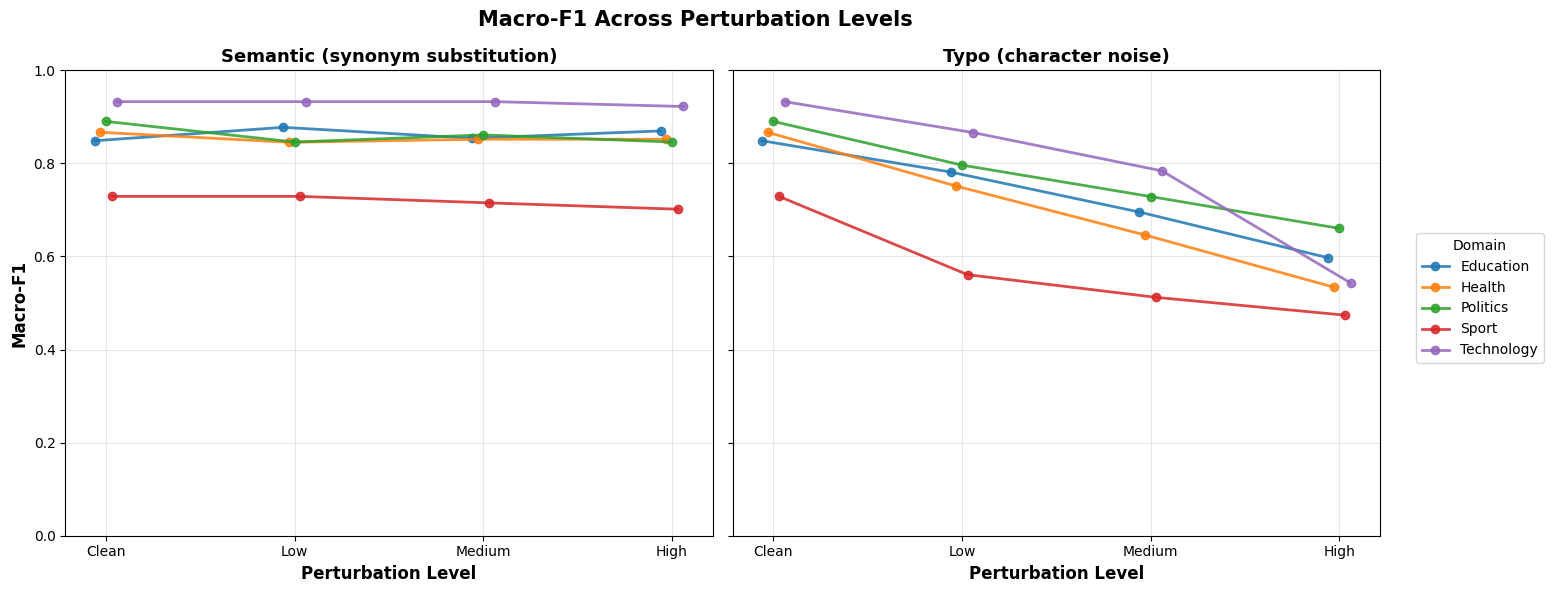

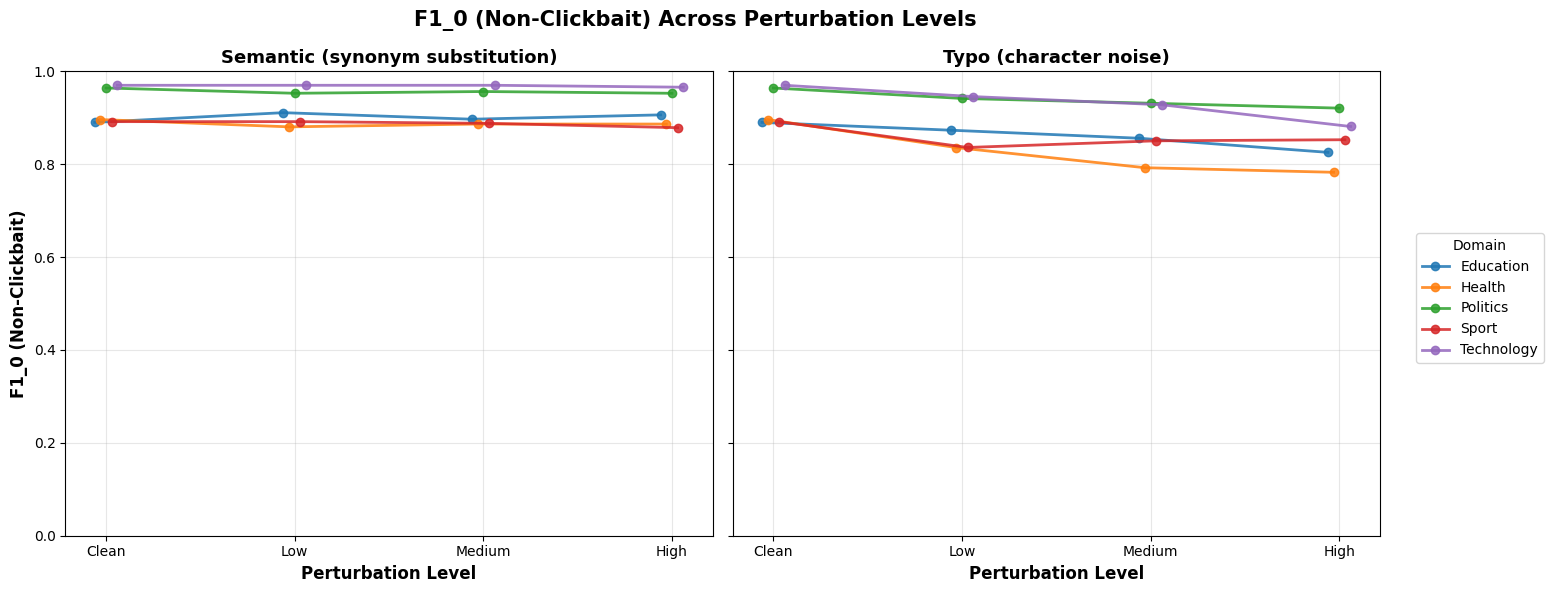

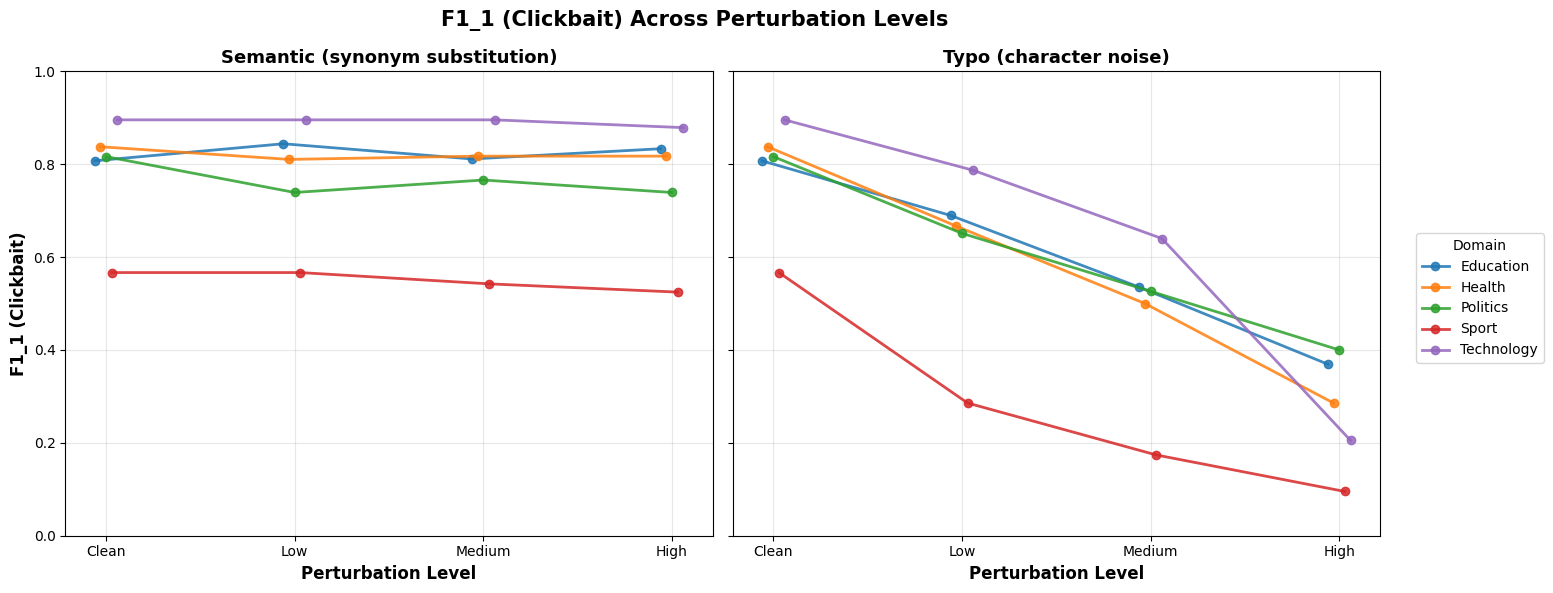

In [34]:
# ── PERTURBATION LINE CHARTS ────────────────────────────────────────────────
# For each metric we draw TWO side-by-side subplots: one for the semantic
# mechanism and one for the typo mechanism. Each subplot shows the 5 domain
# lines across Clean -> Low -> Medium -> High. The Clean point is the shared
# unperturbed baseline, so it appears in both subplots. The subplots share the
# same y-axis so the intensity trend within each mechanism is easy to read.
import matplotlib.pyplot as plt
import numpy as np

# (Assumes DOMAINS, PERTURB_TYPES, PERTURB_LEVELS, PERTURB_SEQUENCE,
#  PERTURB_TYPE_LABELS, clean_metric() and pert_metric() from the table cell above.)

metrics_to_plot = {
    "macro_f1": "Macro-F1",
    "f1_0": "F1_0 (Non-Clickbait)",
    "f1_1": "F1_1 (Clickbait)",
}

x_labels = [lvl.capitalize() for lvl in PERTURB_SEQUENCE]
x_base = np.arange(len(PERTURB_SEQUENCE))
offsets = np.linspace(-0.06, 0.06, len(DOMAINS))

for metric_key, metric_name in metrics_to_plot.items():
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    for ax, ptype in zip(axes, PERTURB_TYPES):
        for idx, domain in enumerate(DOMAINS):
            clean = clean_metric(domain, metric_key)
            values = [clean] + [
                pert_metric(domain, ptype, level, metric_key)
                for level in PERTURB_LEVELS
            ]
            ax.plot(x_base + offsets[idx], values,
                    marker="o", linewidth=2, alpha=0.85, label=domain)

        ax.set_title(PERTURB_TYPE_LABELS[ptype], fontsize=13, fontweight="bold")
        ax.set_xlabel("Perturbation Level", fontsize=12, fontweight="bold")
        ax.set_xticks(x_base)
        ax.set_xticklabels(x_labels)
        ax.set_ylim(0, 1.0)
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel(metric_name, fontsize=12, fontweight="bold")

    # One shared legend to the right of both subplots.
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title="Domain",
               bbox_to_anchor=(1.01, 0.5), loc="center left", frameon=True)

    fig.suptitle(f"{metric_name} Across Perturbation Levels",
                 fontsize=15, fontweight="bold")
    fig.tight_layout()
    plt.show()
    plt.close(fig)


In [35]:
# ── CROSS-DOMAIN PERTURBATION TABLES ────────────────────────────────────────
# Structure: results["cross_domain_perturbation"][pair] = {
#     "clean": {...}, "semantic": {low,medium,high}, "typo": {low,medium,high} }
# We build one tidy DataFrame (with a perturbation_type column) then print
# Macro-F1 tables per source domain, separately for each mechanism.
import json
import os
import pandas as pd

with open(COMPLETE_EVALUATION_JSON, "r") as f:
    data = json.load(f)

DOMAINS = list(data["in_domain"].keys())
PERTURB_TYPES = ["semantic", "typo"]
PERTURB_LEVELS = ["low", "medium", "high"]
PERTURB_SEQUENCE = ["clean", "low", "medium", "high"]
PERTURB_TYPE_LABELS = {
    "semantic": "Semantic (synonym substitution)",
    "typo": "Typo (character noise)",
}

cross_results = data["cross_domain_perturbation"]
print(f"Number of source-target pairs: {len(cross_results)}")

rows = []
for pair, conditions in cross_results.items():
    source, target = pair.split("_to_", 1)

    # Shared clean baseline (type-independent).
    clean_macro = conditions.get("clean", {}).get("metrics", {}).get("macro_f1")

    for ptype in PERTURB_TYPES:
        type_block = conditions.get(ptype, {})
        for level in PERTURB_LEVELS:
            level_block = type_block.get(level)
            if level_block is None:
                continue
            m = level_block["metrics"]
            rows.append({
                "source_domain": source.strip(),
                "target_domain": target.strip(),
                "type": ptype,
                "level": level,
                "macro_f1": m["macro_f1"],
                "clean_macro_f1": clean_macro,
            })

df = pd.DataFrame(rows)

# Print a Macro-F1 table per (mechanism, source domain): rows=target, cols=level.
print("\n" + "#" * 80)
print(f"CROSS-DOMAIN PERTURBATION — MACRO-F1 — {MODEL.upper()}")
print("#" * 80)
for ptype in PERTURB_TYPES:
    for source_domain in DOMAINS:
        sub = df[(df["type"] == ptype) & (df["source_domain"] == source_domain)]
        if sub.empty:
            continue
        table = (
            sub.pivot(index="target_domain", columns="level", values="macro_f1")
               .reindex(index=DOMAINS, columns=PERTURB_LEVELS)
        )
        formatted = table.map(lambda x: f"{x:.4f}" if pd.notna(x) else "-")
        print("\n" + "=" * 80)
        print(f"{PERTURB_TYPE_LABELS[ptype]} | TRAIN DOMAIN: {source_domain.upper()}")
        print("=" * 80)
        print(formatted.to_string())

# Overall average Macro-F1 by (mechanism, level).
print("\n" + "=" * 80)
print("OVERALL CROSS-DOMAIN PERTURBATION (mean Macro-F1 by mechanism/level)")
print("=" * 80)
overall = (
    df.pivot_table(index="level", columns="type",
                   values="macro_f1", aggfunc="mean")
      .reindex(index=PERTURB_LEVELS, columns=PERTURB_TYPES)
)
print(overall.round(4).to_string())


Number of source-target pairs: 25

################################################################################
CROSS-DOMAIN PERTURBATION — MACRO-F1 — BASE
################################################################################

Semantic (synonym substitution) | TRAIN DOMAIN: EDUCATION
level             low  medium    high
target_domain                        
Education      0.8775  0.8541  0.8698
Health         0.6951  0.6680  0.6816
Politics       0.6843  0.6843  0.6843
Sport          0.5122  0.5122  0.5122
Technology     0.8400  0.8479  0.8588

Semantic (synonym substitution) | TRAIN DOMAIN: HEALTH
level             low  medium    high
target_domain                        
Education      0.8857  0.8589  0.8589
Health         0.8454  0.8519  0.8519
Politics       0.7071  0.7071  0.7071
Sport          0.4605  0.4605  0.4605
Technology     0.9206  0.9297  0.9096

Semantic (synonym substitution) | TRAIN DOMAIN: POLITICS
level             low  medium    high
target_domain   

In [36]:
# View training summary
# training_summary.json structure:
#   training_results -> {model_name -> {domain_name -> {best_f1, checkpoint_dir, ...}}}
import json

with open(TRAINING_SUMMARY_JSON, "r") as f:
    training_summary = json.load(f)

print("Training Summary:")
print(f"Total samples: {training_summary['total_samples']}")
print(f"Domains: {', '.join(training_summary['domains'])}")
print(f"\nBest F1 Scores per model per domain:")
for model_name, domain_results in training_summary['training_results'].items():
    print(f"  {model_name.upper()}:")
    for domain_name, info in domain_results.items():
        print(f"    {domain_name}: {info['best_macro_f1']:.4f}")

Training Summary:
Total samples: 5000
Domains: Education, Health, Politics, Sport, Technology

Best F1 Scores per model per domain:
  BASE:
    Education: 0.8939
    Health: 0.8433
    Politics: 0.8658
    Sport: 0.7890
    Technology: 0.8751


In [37]:
# ── EVALUATION SUMMARY: per-model averages, including per-mechanism F1 ───────
import json

with open(EVALUATION_SUMMARY_JSON, "r") as f:
    eval_summary = json.load(f)

print("Evaluation Summary")
print("=" * 50)
for model, metrics in eval_summary["model_summaries"].items():
    print(f"\n{model.upper()}")
    print(f"  Avg In-Domain Macro-F1   : {metrics['avg_in_domain_f1']:.4f}")
    print(f"  Avg Cross-Domain Macro-F1: {metrics['avg_cross_domain_f1']:.4f}")
    # Overall perturbation average (both mechanisms combined).
    if "avg_perturbation_f1" in metrics:
        print(f"  Avg Perturbation Macro-F1: {metrics['avg_perturbation_f1']:.4f}")
    # Per-mechanism averages, if the pipeline wrote them.
    for ptype in ["semantic", "typo"]:
        key = f"avg_{ptype}_f1"
        if key in metrics:
            print(f"    - {ptype.capitalize():<8} Macro-F1: {metrics[key]:.4f}")


Evaluation Summary

BASE
  Avg In-Domain Macro-F1   : 0.8535
  Avg Cross-Domain Macro-F1: 0.7157
  Avg Perturbation Macro-F1: 0.0000


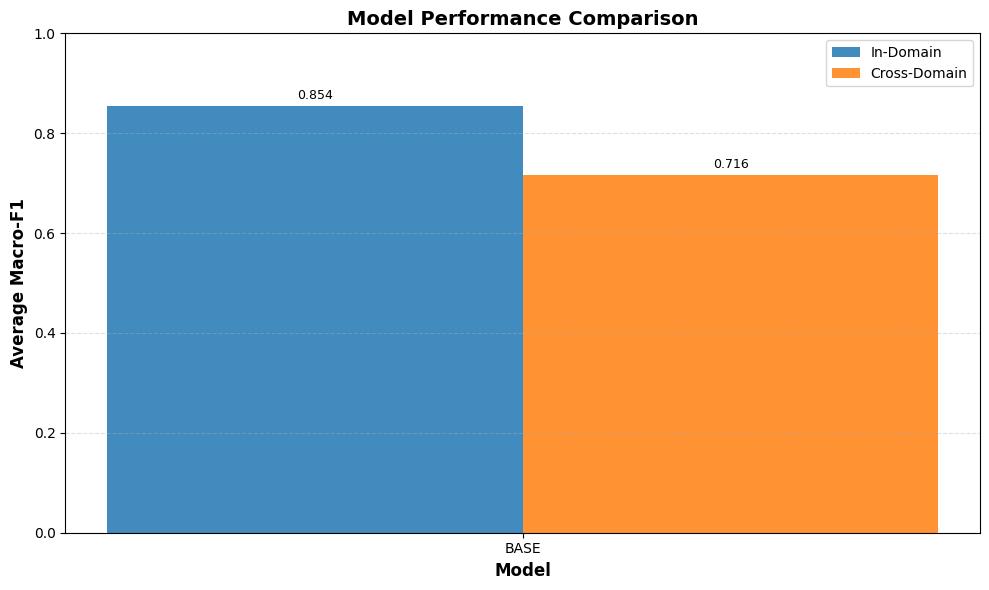

In [38]:
# ── MODEL PERFORMANCE COMPARISON: in-domain vs cross-domain (avg Macro-F1) ──
import matplotlib.pyplot as plt
import numpy as np

models = list(eval_summary["model_summaries"].keys())
in_domain_f1 = [eval_summary["model_summaries"][m]["avg_in_domain_f1"] for m in models]
cross_domain_f1 = [eval_summary["model_summaries"][m]["avg_cross_domain_f1"] for m in models]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width / 2, in_domain_f1, width,
               label="In-Domain", color="tab:blue", alpha=0.85)
bars2 = ax.bar(x + width / 2, cross_domain_f1, width,
               label="Cross-Domain", color="tab:orange", alpha=0.85)

# Value labels on top of each bar for readability.
for bars in (bars1, bars2):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f"{height:.3f}",
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha="center", va="bottom", fontsize=9)

ax.set_xlabel("Model", fontsize=12, fontweight="bold")
ax.set_ylabel("Average Macro-F1", fontsize=12, fontweight="bold")
ax.set_title("Model Performance Comparison", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels([m.upper() for m in models])
ax.set_ylim(0, 1.0)
ax.legend(frameon=True)
ax.grid(axis="y", linestyle="--", alpha=0.4)
fig.tight_layout()
plt.show()
plt.close(fig)


---
### KAGGLE DEBUG
---

In [ ]:
from pathlib import Path
import sys
import pandas as pd
import torch
import transformers

# Kaggle failed dataset
FAILED_CSV = "/content/kaggle_failed_all.csv"

# Your project
PROJECT_ROOT = Path("/content/domain-shift-trustworthy-ai")

PERTURBATION_PY = PROJECT_ROOT / "src" / "perturbation_engine.py"
THESAURUS_PATH = PROJECT_ROOT / "dataset" / "data" / "dict.json"

# Make src importable
sys.path.insert(0, str(PROJECT_ROOT / "src"))

print("Project:", PROJECT_ROOT)
print("Perturbation:", PERTURBATION_PY)
print("Thesaurus:", THESAURUS_PATH)

print("\nEnvironment")
print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("CUDA:", torch.cuda.is_available())
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

Project: /content/domain-shift-trustworthy-ai
Perturbation: /content/domain-shift-trustworthy-ai/src/perturbation_engine.py
Thesaurus: /content/domain-shift-trustworthy-ai/dataset/data/dict.json

Environment
PyTorch: 2.11.0+cu128
Transformers: 5.16.1
CUDA: True
Device: cuda


In [ ]:
from pathlib import Path

path = Path(FAILED_CSV)

with open(path, "rb") as f:
    data = f.read()

print("File size:", len(data))
print("0x96 count:", data.count(b"\x96"))

pos = data.find(b"\x96")
print("First 0x96 position:", pos)

print("\nBytes around first 0x96:")
print(data[pos-100:pos+100])


pos = data.find(b"\x96")

print(data[pos-200:pos+200].decode("utf-8", errors="replace"))


import csv

with open(FAILED_CSV, "rb") as f:
    raw = f.read()

# Find the physical line containing byte 0x96
pos = raw.find(b"\x96")

line_start = raw.rfind(b"\n", 0, pos) + 1
line_end = raw.find(b"\n", pos)

line = raw[line_start:line_end]

print("Line start:", line_start)
print("Line length:", len(line))
print(line[:1000])




File size: 678746
0x96 count: 3
First 0x96 position: 110048

Bytes around first 0x96:
b's;2026-01-27;Prabowo Kembali Kumpulkan Menteri pada Hambalang, Bahas Kerja Sama Pendidikan Indonesia\x96Inggris;0;https://www.tribunnews.com/nasional/7783684/prabowo-kembali-kumpulkan-menteri-di-hambalan'
an', 'serbuan', 'tampikan', 'tantangan', 'tentangan', 'tolakan'], 'position': 9}];[]
102;Tribun News;2026-01-27;Prabowo Kembali Kumpulkan Menteri pada Hambalang, Bahas Kerja Sama Pendidikan Indonesia�Inggris;0;https://www.tribunnews.com/nasional/7783684/prabowo-kembali-kumpulkan-menteri-di-hambalang-bahas-kerja-sama-pendidikan-indonesiainggris;Education;Prabowo Kembali Kumpulkan Menteri di Hambal
Line start: 109934
Line length: 5228
b"102;Tribun News;2026-01-27;Prabowo Kembali Kumpulkan Menteri pada Hambalang, Bahas Kerja Sama Pendidikan Indonesia\x96Inggris;0;https://www.tribunnews.com/nasional/7783684/prabowo-kembali-kumpulkan-menteri-di-hambalang-bahas-kerja-sama-pendidikan-indonesiainggris;Educ

In [ ]:
from perturbation_engine import PerturbationEngine
import pandas as pd

df = pd.read_csv(
    FAILED_CSV,
    encoding="cp1252",
    sep=";",
    engine="python",
    keep_default_na=False
)

print("Total rows:", len(df))
print(df.columns.tolist())

df["kaggle_success"] = (
    (~df["is_same_as_original"])
    & df["similarity_in_range"]
    & df["perturbation_in_range"]
)

kaggle_failed = df.loc[
    ~df["kaggle_success"]
].copy()

print("Kaggle failed:", len(kaggle_failed))
print("Kaggle successful:", df["kaggle_success"].sum())

print(
    kaggle_failed
    .groupby(["domain", "perturbation_level"])
    .size()
    .unstack(fill_value=0)
)

df.head()

config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  498MB            

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  498MB            

model.safetensors: downloading bytes:           |  0.00B            

Total rows: 150
['id', 'source', 'date', 'text', 'label', 'url', 'domain', 'original_text', 'perturbed_text', 'perturbation_level', 'perturbation_rule', 'target_intensity', 'direct_lookup_words', 'reverse_parent_lookup_words', 'stemmed_lookup_words', 'failed_lookup_words', 'total_words', 'eligible_words', 'target_words', 'words_changed', 'actual_ratio_all_words', 'actual_ratio_eligible_words', 'word_cosine_similarity_mean', 'word_cosine_similarity_min', 'word_cosine_similarity_max', 'is_same_as_original', 'similarity_in_range', 'perturbation_in_range', 'diagnostic_stats', 'word_diagnostics', 'replacements']
Kaggle failed: 117
Kaggle successful: 33
perturbation_level  low
domain                 
Education           117


,id,source,date,text,label,url,domain,original_text,perturbed_text,perturbation_level,...,word_cosine_similarity_mean,word_cosine_similarity_min,word_cosine_similarity_max,is_same_as_original,similarity_in_range,perturbation_in_range,diagnostic_stats,word_diagnostics,replacements,kaggle_success
0,719,Detik Edu,2026-05-16,"Beasiswa Telkom University untuk Maba 2026, Bi...",0,https://www.detik.com/edu/beasiswa/d-8491182/b...,Education,"Beasiswa Telkom University untuk Maba 2026, Bi...","Beasiswa Telkom University untuk Maba 2026, Bi...",low,...,,,,True,False,False,"{'words_no_dictionary_entry': 3, 'words_no_syn...","[{'word': 'Beasiswa', 'lookup_found': True, 'l...",[],False
1,781,Detik Edu,2026-05-13,"Usai Sidang Tuntutan Hari Ini, Eks Mendikbud N...",0,https://www.detik.com/edu/detikpedia/d-8487374...,Education,"Usai Sidang Tuntutan Hari Ini, Eks Mendikbud N...","Usai Sidang Tuntutan Hari Ini, Eks Mendikbud N...",low,...,,,,True,False,False,"{'words_no_dictionary_entry': 4, 'words_no_syn...","[{'word': 'Usai', 'lookup_found': True, 'looku...",[],False
2,679,Detik Edu,2026-05-18,AHY: Indonesia Harus Reformasi Pendidikan Kala...,0,https://www.detik.com/edu/edutainment/d-849373...,Education,AHY: Indonesia Harus Reformasi Pendidikan Kala...,AHY: Indonesia Harus Reformasi Pendidikan Kala...,low,...,,,,True,False,False,"{'words_no_dictionary_entry': 2, 'words_no_syn...","[{'word': 'AHY', 'lookup_found': False, 'looku...",[],False
3,186,Tribun News,2025-10-15,"Dukung Pendidikan Anak Bangsa, Pemkot Surabaya...",0,https://www.tribunnews.com/regional/7742313/du...,Education,"Dukung Pendidikan Anak Bangsa, Pemkot Surabaya...","Dukung Pendidikan Anak Bangsa, Pemkot Surabaya...",low,...,,,,True,False,False,"{'words_no_dictionary_entry': 4, 'words_no_syn...","[{'word': 'Dukung', 'lookup_found': True, 'loo...",[],False
4,787,Detik Edu,2026-05-13,"Siswa Bisa Usul Menu MBG Agar Sesuai Selera, S...",1,https://www.detik.com/edu/sekolah/d-8486430/si...,Education,"Siswa Bisa Usul Menu MBG Agar Sesuai Selera, S...","Siswa Bisa Usul Menu MBG Agar Sesuai Selera, S...",low,...,,,,True,False,False,"{'words_no_dictionary_entry': 3, 'words_no_syn...","[{'word': 'Siswa', 'lookup_found': True, 'look...",[],False


In [ ]:
from tqdm.auto import tqdm
import pandas as pd

engine = PerturbationEngine(
    thesaurus_path=str(THESAURUS_PATH),
    random_seed=42,
    sim_min=0.80,
    sim_max=0.95,
)

results = []

# SAME 117 Kaggle-failed rows for every perturbation level
base_df = kaggle_failed.copy()

print("Base rows:", len(base_df))
print()

for level in ["low", "medium", "high"]:

    print("=" * 80)
    print(f"{level.upper()} — SAME Kaggle failures → Colab")
    print("=" * 80)
    print("Rows:", len(base_df))

    result_df = engine.apply_to_dataframe(
        df=base_df.copy(),
        text_column="text",
        level=level,
        output_csv=None,
    )

    result_df["rerun_environment"] = "colab"
    result_df["rerun_level"] = level

    results.append(result_df)

rerun_df = pd.concat(
    results,
    ignore_index=True,
)

print("\nTotal rerun rows:", len(rerun_df))



Base rows: 117

LOW — SAME Kaggle failures → Colab
Rows: 117


Perturbing LOW:   0%|          | 0/117 [00:00<?, ?it/s]


LOW SUCCESS: 110/117 (94.02%)
MEDIUM — SAME Kaggle failures → Colab
Rows: 117


Perturbing MEDIUM:   0%|          | 0/117 [00:00<?, ?it/s]


MEDIUM SUCCESS: 110/117 (94.02%)
HIGH — SAME Kaggle failures → Colab
Rows: 117


Perturbing HIGH:   0%|          | 0/117 [00:00<?, ?it/s]


HIGH SUCCESS: 110/117 (94.02%)

Total rerun rows: 351


OSError: Cannot save file into a non-existent directory: '/contentperturbation_validation'

In [ ]:

# ============================================================
# SAVE RESULT
# ============================================================

output_path = Path("/content/kaggle_failed_rerun_colab.csv")

rerun_df.to_csv(
    output_path,
    index=False,
)

print(f"Saved to: {output_path}")
print(f"Rows saved: {len(rerun_df)}")

Saved to: /content/kaggle_failed_rerun_colab.csv
Rows saved: 351


In [ ]:
rerun_df["colab_success"] = (
    (~rerun_df["is_same_as_original"])
    & rerun_df["similarity_in_range"]
    & rerun_df["perturbation_in_range"]
)

summary = (
    rerun_df
    .groupby(["perturbation_level", "domain"])
    .agg(
        total=("colab_success", "size"),
        success=("colab_success", "sum"),
    )
    .reset_index()
)

summary["failed"] = (
    summary["total"] - summary["success"]
)

summary["success_rate"] = (
    summary["success"] / summary["total"] * 100
)

print(summary.to_string(index=False))

perturbation_level    domain  total  success  failed  success_rate
              high Education    117      110       7     94.017094
               low Education    117      110       7     94.017094
            medium Education    117      110       7     94.017094


In [ ]:
print(kaggle_failed["perturbation_level"].value_counts(dropna=False))

perturbation_level
low    117
Name: count, dtype: int64


In [ ]:
print(rerun_df.columns.tolist())

['id', 'source', 'date', 'text', 'label', 'url', 'domain', 'original_text', 'perturbed_text', 'perturbation_level', 'perturbation_rule', 'target_intensity', 'direct_lookup_words', 'reverse_parent_lookup_words', 'stemmed_lookup_words', 'failed_lookup_words', 'total_words', 'eligible_words', 'target_words', 'words_changed', 'actual_ratio_all_words', 'actual_ratio_eligible_words', 'word_cosine_similarity_mean', 'word_cosine_similarity_min', 'word_cosine_similarity_max', 'is_same_as_original', 'similarity_in_range', 'perturbation_in_range', 'diagnostic_stats', 'word_diagnostics', 'replacements', 'kaggle_success', 'perturbation_success', 'rerun_environment', 'rerun_level', 'colab_success']


In [ ]:
comparison = rerun_df[
    [
        "id",
        "domain",
        "perturbation_level",
        "rerun_level",
        "original_text",
        "perturbed_text",
        "is_same_as_original",
        "similarity_in_range",
        "perturbation_in_range",
        "kaggle_success",
        "colab_success",
        "word_cosine_similarity_mean",
        "word_cosine_similarity_min",
        "word_cosine_similarity_max",
        "eligible_words",
        "target_words",
        "words_changed",
    ]
].copy()

comparison = comparison.rename(
    columns={
        "perturbation_level": "kaggle_level",
        "rerun_level": "colab_level",
    }
)

comparison.head()

,id,domain,kaggle_level,colab_level,original_text,perturbed_text,is_same_as_original,similarity_in_range,perturbation_in_range,kaggle_success,colab_success,word_cosine_similarity_mean,word_cosine_similarity_min,word_cosine_similarity_max,eligible_words,target_words,words_changed
0,719,Education,low,low,"Beasiswa Telkom University untuk Maba 2026, Bi...","Beasiswa Telkom University untuk Maba 2026, Bi...",False,True,True,False,True,0.826823,0.826823,0.826823,2,1,1
1,781,Education,low,low,"Usai Sidang Tuntutan Hari Ini, Eks Mendikbud N...","Usai Sidang Tuntutan Hari Ini, Eks Mendikbud N...",False,True,True,False,True,0.805043,0.805043,0.805043,1,1,1
2,679,Education,low,low,AHY: Indonesia Harus Reformasi Pendidikan Kala...,AHY: Indonesia Harus Reformasi Pendidikan Kala...,False,True,True,False,True,0.854767,0.854767,0.854767,4,1,1
3,186,Education,low,low,"Dukung Pendidikan Anak Bangsa, Pemkot Surabaya...","Dukung Pendidikan Anak Bangsa, Pemkot Surabaya...",False,True,True,False,True,0.860414,0.860414,0.860414,5,1,1
4,787,Education,low,low,"Siswa Bisa Usul Menu MBG Agar Sesuai Selera, S...","Siswa Bisa Usul Menu MBG Supaya Sesuai Selera,...",False,True,True,False,True,0.907139,0.907139,0.907139,3,1,1


In [ ]:
# ============================================================
# CLEAN KAGGLE → COLAB COMPARISON
# ============================================================

final_comparison = comparison.copy()

# Use the existing Kaggle columns
final_comparison = final_comparison.rename(
    columns={
        "kaggle_level_x": "kaggle_level",
        "kaggle_success_x": "kaggle_success",
    }
)

# Make sure Kaggle and Colab levels match
final_comparison["level_match"] = (
    final_comparison["kaggle_level"]
    == final_comparison["colab_level"]
)

# Environment success difference
final_comparison["environment_difference"] = (
    final_comparison["kaggle_success"]
    != final_comparison["colab_success"]
)

print(
    "Rows:",
    len(final_comparison)
)

print(
    "Kaggle FAILED → Colab SUCCESS:",
    (
        (~final_comparison["kaggle_success"])
        & final_comparison["colab_success"]
    ).sum()
)

print(
    "Kaggle FAILED → Colab FAILED:",
    (
        (~final_comparison["kaggle_success"])
        & (~final_comparison["colab_success"])
    ).sum()
)

print(
    "Kaggle SUCCESS → Colab FAILED:",
    (
        final_comparison["kaggle_success"]
        & (~final_comparison["colab_success"])
    ).sum()
)

print(
    "Kaggle SUCCESS → Colab SUCCESS:",
    (
        final_comparison["kaggle_success"]
        & final_comparison["colab_success"]
    ).sum()
)

Rows: 351
Kaggle FAILED → Colab SUCCESS: 330
Kaggle FAILED → Colab FAILED: 21
Kaggle SUCCESS → Colab FAILED: 0
Kaggle SUCCESS → Colab SUCCESS: 0


In [ ]:
print(final_comparison.columns.tolist())

['id', 'domain', 'kaggle_level_x', 'colab_level', 'original_text', 'perturbed_text', 'is_same_as_original', 'similarity_in_range', 'perturbation_in_range', 'kaggle_success_x', 'colab_success', 'word_cosine_similarity_mean', 'word_cosine_similarity_min', 'word_cosine_similarity_max', 'eligible_words', 'target_words', 'words_changed', 'kaggle_level_y', 'kaggle_success_y', 'kaggle_same', 'kaggle_similarity_in_range', 'kaggle_perturbation_in_range', 'kaggle_cosine_mean', 'kaggle_cosine_min', 'kaggle_cosine_max', 'kaggle_eligible_words', 'kaggle_target_words', 'kaggle_words_changed']


In [ ]:
OUTPUT = Path("/content/kaggle_failed_rerun_in_colab.csv")

final_comparison.to_csv(
    OUTPUT,
    index=False,
    encoding="utf-8-sig",
)

print(f"Saved → {OUTPUT}")

Saved → /content/kaggle_failed_rerun_in_colab.csv


---

## 6. Launch Dashboard (Optional)

Launch the interactive Streamlit dashboard for visualization and testing.

In [ ]:
# Install localtunnel for public URL
!npm install -g localtunnel

In [ ]:
# Launch dashboard in background
import subprocess
import threading
import time

def run_streamlit():
    subprocess.run(['streamlit', 'run', 'src/dashboard_app.py', '--server.port', '8501'])

# Start Streamlit in background
thread = threading.Thread(target=run_streamlit, daemon=True)
thread.start()

time.sleep(5)
print("Streamlit is starting...")

In [ ]:
# Create public URL with localtunnel
!lt --port 8501

## 7. Download Results

In [ ]:
# Create zip file of all results
!zip -r results.zip /content/drive/MyDrive/thesis/results/
!zip -r checkpoints.zip /content/drive/MyDrive/thesis/checkpoints/

print("Results and checkpoints zipped successfully!")
print("Files are saved in Google Drive and can be downloaded from there.")